In [ ]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import sys

DEFAULT_CAGI5_HOME = "/workspace-SR003.nfs2/estsoi/CAGI5_benchmark"
DEFAULT_MODEL_PATH = (
    f"{DEFAULT_CAGI5_HOME}/GENA_LM/downstream_tasks/expression_prediction"
)
DEFAULT_GENA_LM_PATH = (
    f"{DEFAULT_CAGI5_HOME}/GENA_LM"
)
DEFAULT_WORK_DIR = (
    f"{DEFAULT_CAGI5_HOME}/GENA_LM/downstream_tasks/expression_prediction/CAGI5_benchmark"
)


os.environ["GENALM_HOME"] = DEFAULT_CAGI5_HOME
os.environ["PYTHONPATH"] = os.pathsep.join(
    part for part in [os.environ.get("PYTHONPATH", ""), DEFAULT_MODEL_PATH, DEFAULT_GENA_LM_PATH, DEFAULT_WORK_DIR] if part
)
if DEFAULT_MODEL_PATH not in sys.path:
    sys.path.append(DEFAULT_MODEL_PATH)
    
if DEFAULT_GENA_LM_PATH not in sys.path:
    sys.path.append(DEFAULT_GENA_LM_PATH)
    
if DEFAULT_WORK_DIR not in sys.path:
    sys.path.append(DEFAULT_WORK_DIR)
    
    
from variant_api.conditions import Condition, DescriptionLookup
from variant_api.contexts import Context, GenomeContext, PlasmidContext, PlasmidRecord
from variant_api.genome import Genome, GenomeRegion
from variant_api.models import SequenceModel, VariantInterpreter
from variant_api.predictions import ExpressionPrediction, PairPrediction, Prediction, TrackPrediction
from variant_api.results import ScoringResult, ScoreWindow, VariantReport
from variant_api.scorers import (
    ExpressionDeltaScorer,
    RegressionScorer,
    ScorerSet,
    TokenWindowScorer,
    TrackFeatureBuilder,
    TrackWindowScorer,
    TrackFeatureScorer
)
from variant_api.sequences import (
    AnnotatedSequence,
    CoordinateMap,
    CoordinateSegment,
    Feature,
    SequencePair,
    SourceCoordinate,
)
from variant_api.tokenization import CenteredTokenizer, TokenizedSequence
from variant_api.variants import Variant
from variant_api.CONST import (
    enhancer_to_mpra_plasmid,
    locations,
    promoter_to_mpra_plasmid,
    table18_primers,
)
from variant_api.plasmids import infer_table18_primer_tails, PlasmidCollection
import json

## Load the expression prediction model

Here we load the GENA-LM expression model through the API wrapper. The wrapper handles the model class import, checkpoint loading, Hydra config, DNA tokenizer, description tokenizer, and device placement.

The DNA-side parameters define how genomic sequence is tokenized around a biological center:

- `dna_max_seq_len=1024`: maximum number of DNA tokens including special tokens.
- `num_before=511`: number of DNA tokens kept upstream of the center.
- `token_len_for_fetch=9`: approximate nucleotide span used when fetching sequence before tokenization.
- `desc_max_seq_len=510`: maximum length for metadata / experiment-description tokens.

This setup uses centered tokenization, so it is intended for coordinate-aware API inference rather than exact reproduction of the original notebook's plain full-sequence tokenization.

In [ ]:
model = SequenceModel.load(model_cls='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/expression_model_final.py::ExpressionCounts',
    checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
    config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/inference_example_config.yaml',
    dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
    description_tokenizer="Qwen/Qwen3-Embedding-0.6B",
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=9,
    device='cuda:5')

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/CAGI5_benchmark/variant_api/models.py:140: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_p

## Select experiment descriptions

`DescriptionLookup` reads ENCODE-style metadata JSON files and deterministically selects one metadata record per requested cell type.

Here we explicitly pin each cell type to a known metadata file ID:

- `K562` -> `ENCFF578UUD`
- `HepG2` -> `ENCFF588KDY`
- `H1` -> `ENCFF081FQX`

The selected metadata records are later converted into natural-language descriptions and passed through the text tokenizer.

In [ ]:
lookup = DescriptionLookup(
    json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata',
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"}, #filter: only one K562 will be selected from all options (by id)
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

## Load the genome and annotations

`Genome` provides FASTA-backed sequence retrieval. We also pass a GTF annotation file, so fetched sequences can carry genomic feature annotations such as genes, transcripts, and exons.

Coordinates used by the API are 0-based by default. The annotation loader converts GTF's 1-based inclusive coordinates into internal 0-based half-open intervals.

In [171]:
genome = Genome(fasta_path='/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa', 
                annotation='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf')

tss_coords = {
    "Sox2": ('chr3', 181711924, '+'),
    "Nanog": ('chr12', 7789414, '+'),
    "HBB": ('chr11', 5227072, '-'),
    'ALB': ('chr4', 73404239, '+')
	   }

(<Figure size 700x1000 with 4 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

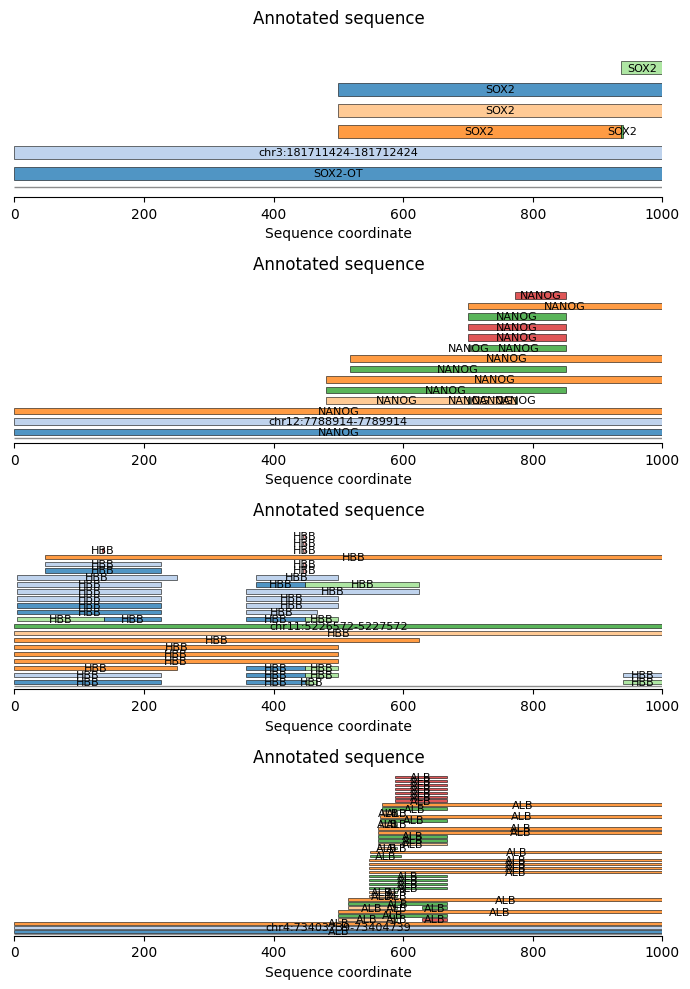

In [191]:
#make sure that TSS is always in the middle
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(7,10))
genome.sequence('chr3', 181711924-500, 181711924+500).plot_annotations(ax=axs[0], show_legend=False, hide_types=('source', 'transcript'))
genome.sequence('chr12', 7789414-500, 7789414+500).plot_annotations(ax=axs[1], show_legend=False)
genome.sequence('chr11', 5227072-500, 5227072+500).plot_annotations(ax=axs[2], show_legend=False)
genome.sequence('chr4', 73404239-500, 73404239+500).plot_annotations(ax=axs[3], show_legend=False)

For every `(cell type, gene)` pair, we fetch a 20 kb sequence centered on the gene's TSS, tokenize it around the TSS, and predict expression under the selected cell-type condition.

Important arguments:

- `genome`: FASTA-backed genome object.
- `chrom`, `tss`, `strand`: genomic TSS definition.
- `condition`: metadata record selected by `DescriptionLookup`.
- `coordinate_system="0-based"`: tells the API that TSS coordinates are already 0-based.
- `dataset_flag=0`: matches the model's inference mode where one description is repeated across multiple DNA inputs.
- `context_bp=20000`: fetches a 20 kb window around the TSS.

The output is a predicted expression value, interpreted as `log(TPM + 1)`.

In [ ]:
results = []
for cell_type in lookup.keys():
    for gene in tss_coords.keys():
        expression = model.predict_expression_at_tss(genome=genome, 
                                        tss=tss_coords[gene][1], 
                                        chrom=tss_coords[gene][0], 
                                        strand=tss_coords[gene][2],
                                        condition=lookup[cell_type],
                                        coordinate_system='0-based',
                                        dataset_flag=0,
                                        context_bp=20000).expression
        results.append(
            (cell_type, gene, expression)
        )

The bar plot compares predicted expression across genes and cell types.

Expected qualitative behavior:

- `ALB` should be high in the liver-derived `HepG2` condition.
- `HBB` should be higher in the blood-related `K562` condition.
- pluripotency-associated genes such as `Sox2` and `Nanog` should be more active in the embryonic stem cell condition `H1`.

   Cell Type   Gene  Expression
0       K562   Sox2    0.059998
1       K562  Nanog    0.129883
2       K562    HBB    1.024414
3       K562    ALB    0.151733
4      HepG2   Sox2    0.241699
5      HepG2  Nanog    0.050995
6      HepG2    HBB    0.072510
7      HepG2    ALB    9.320312
8         H1   Sox2    2.636719
9         H1  Nanog    1.333984
10        H1    HBB    0.029358
11        H1    ALB    0.137451


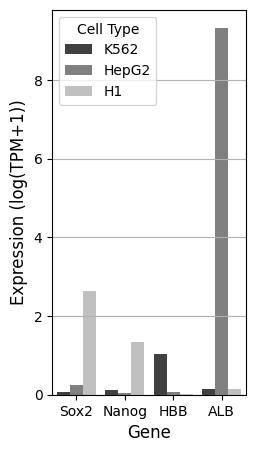

In [170]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.DataFrame(results)
df.columns = ['Cell Type', 'Gene', 'Expression']
print (df)
plt.figure(figsize=(2.5, 5))
sns.barplot(x='Gene', y='Expression', hue='Cell Type', data=df, palette='gray')
plt.xlabel('Gene', fontsize=12)
plt.ylabel('Expression (log(TPM+1))', fontsize=12)
plt.grid(True, axis='y')
plt.show()

In [78]:
model = SequenceModel.load(model_cls='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/expression_model_final.py::ExpressionCounts',
    checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
    config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/inference_example_config.yaml',
    dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
    description_tokenizer="Qwen/Qwen3-Embedding-0.6B",
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=9,
    device='cuda:5')

/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/CAGI5_benchmark/variant_api/models.py:140: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large
missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_p

In [72]:
lookup = DescriptionLookup(
    json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata',
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

In [5]:
genome = Genome(fasta_path='/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa', 
                annotation='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf')

In [ ]:
7789395

In [101]:
genome.sequence('chr12', 7789414-500, 7789414+500).feature_frame()

,name,start,end,type,strand,source,metadata
0,chr12:7788914-7789914,0,1000,genome_interval,+,genome,"{'chrom': 'chr12', 'start': 7788914, 'end': 77..."
1,NANOG,0,1000,transcript,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7787793, '..."
2,NANOG,0,1000,gene,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7787793, '..."
3,NANOG,481,700,UTR,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7789395, '..."
4,NANOG,481,851,exon,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7789395, '..."
5,NANOG,481,1000,transcript,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7789395, '..."
6,NANOG,518,851,exon,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7789432, '..."
7,NANOG,518,1000,transcript,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7789432, '..."
8,NANOG,700,703,start_codon,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7789614, '..."
9,NANOG,700,703,start_codon,+,HAVANA,"{'chrom': 'chr12', 'genomic_start': 7789614, '..."


(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

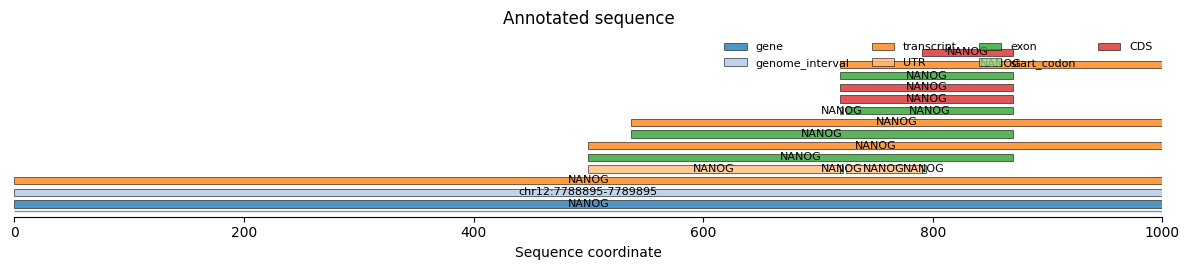

In [123]:
genome.sequence('chr12', 7789395-500, 7789395+500).plot_annotations()

In [125]:
output = model.predict_expression_at_tss(genome=genome, 
                                        tss=tss_coords['Nanog'][1], 
                                        chrom=tss_coords['Nanog'][0], 
                                        strand=tss_coords['Nanog'][2],
                                        condition=lookup['K562'],
                                        coordinate_system='0-based',
                                        dataset_flag=1)

In [126]:
output.expression

0.1290283203125

In [55]:
output.sequence.sequence.find('TTATAAATCTAGAGACTCCAGGATTTTAACG')

6204

In [57]:
6204-4599

1605

In [56]:
9198//2

4599

In [129]:
import polars as pl

In [136]:
annotation = pl.read_csv('/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf',
                            separator='\t',
                            comment_prefix='#')

In [ ]:
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},

In [138]:
from pathlib import Path
import polars as pl


def load_gene_name_to_id(annotation_path: str | Path) -> dict[str, str]:
    """Load a GTF annotation and return {gene_name: gene_id} for gene rows."""

    annotation_path = Path(annotation_path)

    gtf = pl.read_csv(
        annotation_path,
        separator="\t",
        has_header=False,
        comment_prefix="#",
        new_columns=[
            "chrom",
            "source",
            "feature",
            "start",
            "end",
            "score",
            "strand",
            "frame",
            "attributes",
        ],
    )

    genes = (
        gtf
        .filter(pl.col("feature") == "gene")
        .with_columns(
            gene_id=pl.col("attributes").str.extract(r'gene_id "([^"]+)"', 1),
            gene_name=pl.col("attributes").str.extract(r'gene_name "([^"]+)"', 1),
        )
        .filter(pl.col("gene_id").is_not_null() & pl.col("gene_name").is_not_null())
        .select("gene_name", "gene_id")
        .unique(subset=["gene_name"], keep="first")
    )

    return dict(zip(genes["gene_name"].to_list(), genes["gene_id"].to_list()))

In [140]:
gene2gene_id = load_gene_name_to_id('/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf')

In [146]:
gene2gene_id

{'IRF2BPL': 'ENSG00000119669.4',
 'AC104791.2': 'ENSG00000279481.1',
 'AL163195.1': 'ENSG00000239327.1',
 'RNU6-130P': 'ENSG00000223044.1',
 'KLHL36': 'ENSG00000135686.12',
 'LINC00649': 'ENSG00000237945.7',
 'AL353613.2': 'ENSG00000285686.1',
 'KRT17P5': 'ENSG00000205266.10',
 'AP000462.3': 'ENSG00000256972.1',
 'AP002884.2': 'ENSG00000254638.1',
 'SNORD3J': 'ENSG00000221400.2',
 'SLFN11': 'ENSG00000172716.16',
 'AL121672.3': 'ENSG00000273289.1',
 'AP001972.1': 'ENSG00000254429.1',
 'INE2': 'ENSG00000281371.1',
 'SACS': 'ENSG00000151835.15',
 'TP53I13': 'ENSG00000167543.15',
 'AC089987.1': 'ENSG00000197376.3',
 'FAM9A': 'ENSG00000183304.10',
 'AL442163.3': 'ENSG00000258622.2',
 'FP325318.1': 'ENSG00000276266.1',
 'HK2P1': 'ENSG00000228612.2',
 'PRR33': 'ENSG00000283787.1',
 'KMO': 'ENSG00000117009.11',
 'LY6K': 'ENSG00000160886.13',
 'AL022476.1': 'ENSG00000230319.1',
 'LINC02024': 'ENSG00000241213.1',
 'CCDC81': 'ENSG00000149201.9',
 'VTI1A': 'ENSG00000151532.13',
 'STARD7-AS1': 'ENS

In [152]:
def id2expression(id, gene):
    expr = pl.read_csv(f'/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/tpm/{id}_qnorm.csv', has_header=False) \
        .transpose(column_names=['gene_id', 'expression']).cast({'expression':pl.Float64}) \
        .with_columns(gene_name = pl.col.gene_id.replace_strict({v:k for k,v in gene2gene_id.items()}, default=None)) \
        .filter(pl.col.gene_name == gene)
    return expr

In [163]:
id2expression('ENCFF578UUD', 'ALB') #K562

gene_id,expression,gene_name
str,f64,str
"""ENSG00000163631.16""",0.448081,"""ALB"""


In [164]:
id2expression('ENCFF588KDY', 'ALB') #HepG2

gene_id,expression,gene_name
str,f64,str
"""ENSG00000163631.16""",8708.74014,"""ALB"""


In [165]:
id2expression('ENCFF081FQX', 'ALB') #H1

gene_id,expression,gene_name
str,f64,str
"""ENSG00000163631.16""",0.094257,"""ALB"""


In [149]:
pl.read_csv('/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/tpm/ENCFF578UUD_qnorm.csv', has_header=False) \
    .transpose(column_names=['gene_id', 'expression']).cast({'expression':pl.Float64}) \
    .with_columns(gene_name = pl.col.gene_id.replace_strict({v:k for k,v in gene2gene_id.items()}, default=None)) \
    .filter(pl.col.gene_name == 'NANOG')

gene_id,expression,gene_name
str,f64,str
"""ENSG00000111704.10""",0.032829,"""NANOG"""


In [150]:
pl.read_csv('/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/tpm/ENCFF588KDY_qnorm.csv', has_header=False) \
    .transpose(column_names=['gene_id', 'expression']).cast({'expression':pl.Float64}) \
    .with_columns(gene_name = pl.col.gene_id.replace_strict({v:k for k,v in gene2gene_id.items()}, default=None)) \
    .filter(pl.col.gene_name == 'NANOG')

gene_id,expression,gene_name
str,f64,str
"""ENSG00000111704.10""",0.694757,"""NANOG"""


In [127]:
results = []
for cell_type in lookup.keys():
    for gene in tss_coords.keys():
        expression = model.predict_expression_at_tss(genome=genome, 
                                        tss=tss_coords[gene][1], 
                                        chrom=tss_coords[gene][0], 
                                        strand=tss_coords[gene][2],
                                        condition=lookup[cell_type],
                                        coordinate_system='0-based',
                                        dataset_flag=0,
                                        context_bp=20000).expression
        results.append(
            (cell_type, gene, expression)
        )

   Cell Type   Gene  Expression
0       K562   Sox2    0.059998
1       K562  Nanog    0.129028
2       K562    HBB    1.024414
3       K562    ALB    0.151733
4      HepG2   Sox2    0.241699
5      HepG2  Nanog    0.095886
6      HepG2    HBB    0.072510
7      HepG2    ALB    9.320312
8         H1   Sox2    2.636719
9         H1  Nanog    1.058594
10        H1    HBB    0.029358
11        H1    ALB    0.137451


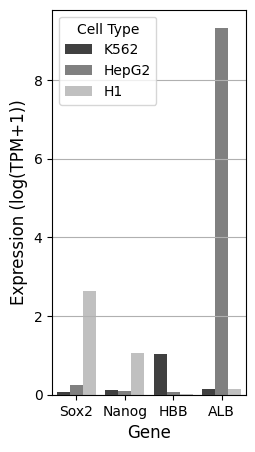

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.DataFrame(results)
df.columns = ['Cell Type', 'Gene', 'Expression']

print (df)


plt.figure(figsize=(2.5, 5))
sns.barplot(x='Gene', y='Expression', hue='Cell Type', data=df, palette='gray')
plt.xlabel('Gene', fontsize=12)
plt.ylabel('Expression (log(TPM+1))', fontsize=12)
plt.grid(True, axis='y')
plt.show()

In [120]:
sequences_by_gene={'HBB': 'GTTTTGATCACAACATTTTGAATTGACTGGCAGCAGAAGCTCTTTTATATCCATGTGTTTTCCTTAAGTCATTATACATAGTAGGCACTGAGAACTCTTTATATCTGAATAAGATATTTAGGAACCACTGGTTTACATATCAGAAGCAGAGCTACTCAGGGCATTTTGGGGAAGATCACTTTCACATTCCTGAGCATAGGGAAGTTCTCATAAGAGTAAGATATTAAAAGGAGATACTTGTGTGGTATTCGAAAGACAGTAAGAGAGATTGTAGACCTTATGATCTTGATAGGGAAAACAAACTACATTCCTTTCTCCAAAAGTCAAAAAAAAAGAGCAAATATAGCTTACTATACCTTCTATTCCTACACCATTAGAAGTAGTCAGTGAGTCTAGGCAAGATGTTGGCCCTAAAAATCCAAATACCAGAGAATTCATGAGAACATCACCTGGATGGGACATGTGCCGAGCACACACAATTACTATATGCTAGGCATTGCTATCTTCATATTGAAGATGAGGAGGTCAAGAGATGAAAAAAGACTTGGCACCTTGTTGTTATATTAAAATTATTTGTTAGAGTAGAGCTTTTGTAAGAGTCTAGGAGTGTGGGAGCTAAATGATGATACACATGGACACAAAAAATAGATCAACAGACACCCAGGCCTACTTGAGGGTTGAGGGTGGGAAGAGGGAGACGATGAAAAAGAACCTATTGGGTATTAAGTTCATCACTGAGTGATGAAATAATCTGTACATCAAGACCCAGTGATATGCAATTTACCTATATAACTTGTACATGTACCCCCAAATTTAAAATGAAAGTTAAAACAAAGTATAGGAATGGAATTAATTCCTCAAGATTTGGCTTTAATTTTATTTGATAATTTATCAAATGGTTGTTTTTCTTTTCTCACTATGGCGTTGCTTTATAAACTATGTTCAGTATGTCTGAATGAAAGGGTGTGTGTGTGTGTGAAAGAGAGGGAGAGAGGAAGGGAAGAGAGGACGTAATAATGTGAATTTGAGTTCATGAAAATTTTTCAATAAAATAATTTAATGTCAGGAGAATTAAGCCTAATAGTCTCCTAAATCATCCATCTCTTGAGCTTCAGAGCAGTCCTCTGAATTAATGCCTACATGTTTGTAAAGGGTGTTCAGACTGAAGCCAAGATTCTACCTCTAAAGAGATGCAATCTCAAATTTATCTGAAGACTGTACCTCTGCTCTCCATAAATTGACACCATGGCCCACTTAATGAGGTTAAAAAAAAGCTAATTCTGAATGAAAATCTGAGCCCAGTGGAGGAAATATTAATGAACAAGGTGCAGACTGAAATATAAATTTTTCTGTAATAATTATGCATATACTTTAGCAAAGTTCTGTCTATGTTGACTTTATTGCTTTTTGGTAAGAAATACAACTTTTTAAAGTGAACTAAACTATCCTATTTCCAAACTATTTTGTGTGTGTGCGGTTTGTTTCTATGGGTTCTGGTTTTCTTGGAGCATTTTTATTTCATTTTAATTAATTAATTCTGAGAGCTGCTGAGTTGTGTTTACTGAGAGATTGTGTATCTGCGAGAGAAGTCTGTAGCAAGTAGCTAGACTGTGCTTGACCTAGGAACATATACAGTAGATTGCTAAAATGTCTCACTTGGGGAATTTTAGACTAAACAGTAGAGCATGTATAAAAATACTCTAGTCAAGTGCTGCTTTTGAAACAAATGATAAAACCACACTCCCATAGATGAGTGTCATGATTTTCATGGAGGAAGTTAATATTCATCCTCTAAGTATACCCAGACTAGGGCCATTCTGATATAAAACATTAGGACTTAAGAAAGATTAATAGACTGGAGTAAAGGAAATGGACCTCTGTCTCTCTCGCTGTCTCTTTTTTGAGGACTTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTTGTGGTCAGTGGGGCTGGAATAAAAGTAGAATAGACCTGCACCTGCTGTGGCATCCATTCACAGAGTAGAAGCAAGCTCACAATAGTGAAGATGTCAGTAAGCTTGAATAGTTTTTCAGGAACTTTGAATGCTGATTTAGATTTGAAACTGAGGCTCTGACCATAACCAAATTTGCACTATTTATTGCTTCTTGAAACTTATTTGCCTGGTATGCCTGGGCTTTTGATGGTCTTAGTATAGCTTGCAGCCTTGTCCCTGCAGGGTATTATGGGTAATAGAAAGAAAAGTCTGCGTTACACTCTAGTCACACTAAGTAACTACCATTGGAAAAGCAACCCCTGCCTTGAAGCCAGGATGATGGTATCTGCAGCAGTTGCCAACACAAGAGAAGGATCCATAGTTCATCATTTAAAAAAGAAAACAAAATAGAAAAAGGAAAACTATTTCTGAGCATAAGAAGTTGTAGGGTAAGTCTTTAAGAAGGTGACAATTTCTGCCAATCAGGATTTCAAAGCTCTTGCTTTGACAATTTTGGTCTTTCAGAATACTATAAATATAACCTATATTATAATTTCATAAAGTCTGTGCATTTTCTTTGACCCAGGATATTTGCAAAAGACATATTCAAACTTCCGCAGAACACTTTATTTCACATATACATGCCTCTTATATCAGGGATGTGAAACAGGGTCTTGAAAACTGTCTAAATCTAAAACAATGCTAATGCAGGTTTAAATTTAATAAAATAAAATCCAAAATCTAACAGCCAAGTCAAATCTGCATGTTTTAACATTTAAAATATTTTAAAGACGTCTTTTCCCAGGATTCAACATGTGAAATCTTTTCTCAGGGATACACGTGTGCCTAGATCCTCATTGCTTTAGTTTTTTACAGAGGAATGAATATAAAAAGAAAATACTTAAATTTTATCCCTCTTACCTCTATAATCATACATAGGCATAATTTTTTAACCTAGGCTCCAGATAGCCATAGAAGAACCAAACACTTTCTGCGTGTGTGAGAATAATCAGAGTGAGATTTTTTCACAAGTACCTGATGAGGGTTGAGACAGGTAGAAAAAGTGAGAGATCTCTATTTATTTAGCAATAATAGAGAAAGCATTTAAGAGAATAAAGCAATGGAAATAAGAAATTTGTAAATTTCCTTCTGATAACTAGAAATAGAGGATCCAGTTTCTTTTGGTTAACCTAAATTTTATTTCATTTTATTGTTTTATTTTATTTTATTTTATTTTATTTTGTGTAATCGTAGTTTCAGAGTGTTAGAGCTGAAAGGAAGAAGTAGGAGAAACATGCAAAGTAAAAGTATAACACTTTCCTTACTAAACCGACATGGGTTTCCAGGTAGGGGCAGGATTCAGGATGACTGACAGGGCCCTTAGGGAACACTGAGACCCTACGCTGACCTCATAAATGCTTGCTACCTTTGCTGTTTTAATTACATCTTTTAATAGCAGGAAGCAGAACTCTGCACTTCAAAAGTTTTTCCTCACCTGAGGAGTTAATTTAGTACAAGGGGAAAAAGTACAGGGGGATGGGAGAAAGGCGATCACGTTGGGAAGCTATAGAGAAAGAAGAGTAAATTTTAGTAAAGGAGGTTTAAACAAACAAAATATAAAGAGAAATAGGAACTTGAATCAAGGAAATGATTTTAAAACGCAGTATTCTTAGTGGACTAGAGGAAAAAAATAATCTGAGCCAAGTAGAAGACCTTTTCCCCTCCTACCCCTACTTTCTAAGTCACAGAGGCTTTTTGTTCCCCCAGACACTCTTGCAGATTAGTCCAGGCAGAAACAGTTAGATGTCCCCAGTTAACCTCCTATTTGACACCACTGATTACCCCATTGATAGTCACACTTTGGGTTGTAAGTGACTTTTTATTTATTTGTATTTTTGACTGCATTAAGAGGTCTCTAGTTTTTTATCTCTTGTTTCCCAAAACCTAATAAGTAACTAATGCACAGAGCACATTGATTTGTATTTATTCTATTTTTAGACATAATTTATTAGCATGCATGAGCAAATTAAGAAAAACAACAACAAATGAATGCATATATATGTATATGTATGTGTGTATATATACACACATATATATATATATTTTTTCTTTTCTTACCAGAAGGTTTTAATCCAAATAAGGAGAAGATATGCTTAGAACCGAGGTAGAGTTTTCATCCATTCTGTCCTGTAAGTATTTTGCATATTCTGGAGACGCAGGAAGAGATCCATCTACATATCCCAAAGCTGAATTATGGTAGACAAAACTCTTCCACTTTTAGTGCATCAACTTCTTATTTGTGTAATAAGAAAATTGGGAAAACGATCTTCAATATGCTTACCAAGCTGTGATTCCAAATATTACGTAAATACACTTGCAAAGGAGGATGTTTTTAGTAGCAATTTGTACTGATGGTATGGGGCCAAGAGATATATCTTAGAGGGAGGGCTGAGGGTTTGAAGTCCAACTCCTAAGCCAGTGCCAGAAGAGCCAAGGACAGGTACGGCTGTCATCACTTAGACCTCACCCTGTGGAGCCACACCCTAGGGTTGGCCAATCTACTCCCAGGAGCAGGGAGGGCAGGAGCCAGGGCTGGGCATAAAAGTCAGGGCAGAGCCATCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGTTGGTATCAAGGTTACAAGACAGGTTTAAGGAGACCAATAGAAACTGGGCATGTGGAGACAGAGAAGACTCTTGGGTTTCTGATAGGCACTGACTCTCTCTGCCTATTGGTCTATTTTCCCACCCTTAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGGGGATCTGTCCACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGTGCCTTTAGTGATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACTGTGACAAGCTGCACGTGGATCCTGAGAACTTCAGGGTGAGTCTATGGGACGCTTGATGTTTTCTTTCCCCTTCTTTTCTATGGTTAAGTTCATGTCATAGGAAGGGGATAAGTAACAGGGTACAGTTTAGAATGGGAAACAGACGAATGATTGCATCAGTGTGGAAGTCTCAGGATCGTTTTAGTTTCTTTTATTTGCTGTTCATAACAATTGTTTTCTTTTGTTTAATTCTTGCTTTCTTTTTTTTTCTTCTCCGCAATTTTTACTATTATACTTAATGCCTTAACATTGTGTATAACAAAAGGAAATATCTCTGAGATACATTAAGTAACTTAAAAAAAAACTTTACACAGTCTGCCTAGTACATTACTATTTGGAATATATGTGTGCTTATTTGCATATTCATAATCTCCCTACTTTATTTTCTTTTATTTTTAATTGATACATAATCATTATACATATTTATGGGTTAAAGTGTAATGTTTTAATATGTGTACACATATTGACCAAATCAGGGTAATTTTGCATTTGTAATTTTAAAAAATGCTTTCTTCTTTTAATATACTTTTTTGTTTATCTTATTTCTAATACTTTCCCTAATCTCTTTCTTTCAGGGCAATAATGATACAATGTATCATGCCTCTTTGCACCATTCTAAAGAATAACAGTGATAATTTCTGGGTTAAGGCAATAGCAATATCTCTGCATATAAATATTTCTGCATATAAATTGTAACTGATGTAAGAGGTTTCATATTGCTAATAGCAGCTACAATCCAGCTACCATTCTGCTTTTATTTTATGGTTGGGATAAGGCTGGATTATTCTGAGTCCAAGCTAGGCCCTTTTGCTAATCATGTTCATACCTCTTATCTTCCTCCCACAGCTCCTGGGCAACGTGCTGGTCTGTGTGCTGGCCCATCACTTTGGCAAAGAATTCACCCCACCAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGTGTGGCTAATGCCCTGGCCCACAAGTATCACTAAGCTCGCTTTCTTGCTGTCCAATTTCTATTAAAGGTTCCTTTGTTCCCTAAGTCCAACTACTAAACTGGGGGATATTATGAAGGGCCTTGAGCATCTGGATTCTGCCTAATAAAAAACATTTATTTTCATTGCAATGATGTATTTAAATTATTTCTGAATATTTTACTAAAAAGGGAATGTGGGAGGTCAGTGCATTTAAAACATAAAGAAATGAAGAGCTAGTTCAAACCTTGGGAAAATACACTATATCTTAAACTCCATGAAAGAAGGTGAGGCTGCAAACAGCTAATGCACATTGGCAACAGCCCCTGATGCATATGCCTTATTCATCCCTCAGAAAAGGATTCAAGTAGAGGCTTGATTTGGAGGTTAAAGTTTTGCTATGCTGTATTTTACATTACTTATTGTTTTAGCTGTCCTCATGAATGTCTTTTCACTACCCATTTGCTTATCCTGCATCTCTCAGCCTTGACTCCACTCAGTTCTCTTGCTTAGAGATACCACCTTTCCCCTGAAGTGTTCCTTCCATGTTTTACGGCGAGATGGTTTCTCCTCGCCTGGCCACTCAGCCTTAGTTGTCTCTGTTGTCTTATAGAGGTCTACTTGAAGAAGGAAAAACAGGGGTCATGGTTTGACTGTCCTGTGAGCCCTTCTTCCCTGCCTCCCCCACTCACAGTGACCCGGAATCTGCAGTGCTAGTCTCCCGGAACTATCACTCTTTCACAGTCTGCTTTGGAAGGACTGGGCTTAGTATGAAAAGTTAGGACTGAGAAGAATTTGAAAGGCGGCTTTTTGTAGCTTGATATTCACTACTGTCTTATTACCCTGTCATAGGCCCACCCCAAATGGAAGTCCCATTCTTCCTCAGGATGTTTAAGATTAGCATTCAGGAAGAGATCAGAGGTCTGCTGGCTCCCTTATCATGTCCCTTATGGTGCTTCTGGCTCTGCAGTTATTAGCATAGTGTTACCATCAACCACCTTAACTTCATTTTTCTTATTCAATACCTAGGTAGGTAGATGCTAGATTCTGGAAATAAAATATGAGTCTCAAGTGGTCCTTGTCCTCTCTCCCAGTCAAATTCTGAATCTAGTTGGCAAGATTCTGAAATCAAGGCATATAATCAGTAATAAGTGATGATAGAAGGGTATATAGAAGAATTTTATTATATGAGAGGGTGAAACCCTCAAAATGAAATGAAATCAGACCCTTGTCTTACACCATAAACAAAAATAAATTTGAATGGGTTAAAGAATTAAACTAAGACCTAAAACCATAAAAATTTTTAAAGAAATCAAAAGAAGAAAATTCTAATATTCACGTTGCAGCCGTTTTTTGAATTTGATATGAGAAGCAAAGGCAACAAAAGGAAAAATAAAGAAGTGAGGCTACATCAAACTAAAAAATTTCCACACAAAAAACAAAACAATGAACAAATGAAAGGTGAACCATGAAATGGCATATTTGCAAACCAAATATTTCTTAAATATTTTGGTTAATATCCAAAATATATAAGAAACACAGATGATTCAATAACAAACAAAAAATTAAAAATAGGAAAATAAAAAAATTAAAAAGAAGAAAATCCTGCCATTTATGGCAGAATTGATGAACCTGGAGGATGTAAAACTAAGAAAAATAAGCCTGACACAAAAAGACAAATACTACACAACCTTGCTCATATGTGAAACATAAAAAAGTCACTCTCATGGAAACAGACAGTAGAGGTATGGTTTCCAGGGGTTGGGGGTGGGAGAATCAGGAAACTATTACTCAAAGGGTATAAAATTTCAGTTATGTGGGATGAATAAATTCTAGATATCTAATGTACAGCATCGTGACTGTAGTTAATTGTACTGTAAGTATATTTAAAATTTGCAAAGAGAGTAGATTTTTTTTTTTTTTTAGATGGAGTTTTGCTCTTGTTGTCCAGGCTGGAGTGCAATGGCAAGATCTTGGCTCACTGCAACCTCCGCCTCCTGGGTTCAAGCAAATCTCCTGCCTCAGCCTCCCGAGTAGCTGGGATTACAGGCATGCGACACCATGCCCAGCTAATTTTGTATTTTTAGTAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGATCCGCCTGCCTCGGCCACCCAAAGGGCTGGGATTACAGGCGTGAGCCACCGGGCCTGGCCGAGAGTAGATCTTAAAAGCATTTACCACAAGAAAAAGGTAACTATGTGAGATAATGGGTATGTTAATTAGCTTGATTGTGGTAATCATTTCACAAGGTATACATATATTAAAACATCATGTTGTACACCTTAAATATATACAATTTTTATTTGTGAATGATACCTCAATAAAGTTGAAGAATAATAAAAAAGAATAGACATCACATGAATTAAAAAACTAAAAAATAAAAAAATGCATCTTGATGATTAGAATTGCATTCTTGATTTTTCAGATACAAATATCCATTTGACTGTTTACTCTTTTCCAAAACAATACAATAAATTTTAGCACTTTATCTTCATTTTCCCCTTCCCAATCTATAATTATATATATATATATTTTAGATATTTTGTATAGTTTTACTCCCTAGATTTTCTAGTGTTATTATTAAATAGTGAAGAAATGTTTACACTTATGTACAAAATGTTTTGCATGCTTTTCTTCATTTCTAACATTCTCTCTAAGTTTATTCTATTTTTTTCTGATTATCCTTAATATTATCTCTTTCTGCTGGAAATACATTGTTACTTTTGGTTTATCTAAAAATGGCTTCATTTTCTTCATTCTAAAATCATGTTAAATTAATACCACTCATGTGTAAGTAAGATAGTGGAATAAATAGAAATCCAAAAACTAAATCTCACTAAAATATAATAATGTGATATATAAAAATATAGCTTTTAAATTTAGCTTGGAAATAAAAAACAAACAGTAATTGAACAACTATACTTTTTGAAAAGAGTAAAGTGAAATGCTTAACTGCATATACCACAATCGATTACACAATTAGGTGTGAAGGTAAAATTCAGTCACGAAAAAACTAGAATAAAAATATGGGAAGACATGTATATAATCTTAGAGATAACACTGTTATTTAATTATCAACCCAAAGTAGAAACTATCAAGGGAGAAATAAATTCAGTCAACAA',
 'ALB': 'ATTTCAACATGAGACTATTTTAGCTATACAATCTTAGTTGTTTTATAGAAGATTGATAAAGTTCAATTTTATAACTTTAAACTTAAGTAACAAGTTTCTTGAATTTCATGTTTAAAATATAGAATATGAATAGATTCAAAGTGCATTCATTTCTGTTTAATTTCCATCTGTGGCTATCCTTATGAGACAGGATTAGTATTAATTTCAATTTATATGTTTATAGATTCTATTAGTTGTTAATTTATTAAGAATGGATAAACATGGATTGCAGACATTAACTATATTTTTCTTGCACTTGAAAAACTTGATAAAAAAATATGAGAAAGTCTCATTAATATAGTTTAAATAAGTTTAAATGAACTTTTTATTCTTTAAAAATATTAAGCTGAACTAGCTAGAGCGTAATACTTGAGGAGCAATTGTGAGGCTTAGGAATGAACAAGCTCTCAAACTTGAATCCTAATTGCCTAACTTGATATATTCTTTCCTACCACTCAGGTCCTTTTCTCATTTGATAAGGCTGTCACATTGAAAACATGGAATTGCAGAATGTTCAAGGTAGAAGGATCGTTAAAGATAATTTAGTCCAACTTGACCCATATGGCATAGAGATATATGCAGATCTGCATGTCCAGTTCTGCAGCTAGAAACTGACACTGAGCTGAATTAAACCACACGGAGAAGAACTGAGAAATTTAAAGTAAAAGGTTAGGAAATTCGAATGTATATATATTCCAGAGGCCCAGTGTAACATGAAGAAAGTCAAGGAGAGGGACTCTTTCATCATGGAAGATCTGGGGGCAGAGGGACTTAAAAGGTGGGACAAGCCAAAGATGGTGACCTAGGGTGGTTTTTATGATATAACCTTTTTTCTCCTCATTCCCTATGAAATCTTCAGCCAATTCCATATTTCTCACTAATTCAAGTGAATATCTGGGGGGATGGCTTATGGAGGGAAATAAGGGAGCAATTGTTTGGATTATATTCCAATTTTTTATTTGCATTAGAATACCTATATGTTTATACATTTTTATTTGCATTAGAAATACTTATATAAGTTTATACACTTTCATTCTAACTTTTTTTGAGGGAAATGTATCTCCATAAGTGAATAAGAAGTTAAATTACTGATTATGTTTCAATTGGTTAGTTTGATGCTTAACAGTCTTTCACTTTTCCACTCTTGCATATTTTGTAGAGAGTAATACAAGCTCTTCATGATAGGAAGGATCTGCATATGTTTATTTTATAGTAGAAAAATGGTAAGATTTTCCTGTCCCCAATTTTCTCTCCAAACAAATCCAAATTTCTTGTATTTTGGAATGACTCTGGGTAAAGTGGTTGTTTATAGAAAGTCTCTTATAAAATATTGAGGATATTATTAGATATTATTACATTTCCATGAATATGTTTCCCTTTATCTTTAAGAGAAGAAGAGTCAGAAATATAACCTATCAGAGTGGGAGATGGCATAAAAGCTGGACTAAATGGATTGCTAGATGGAGGGCAAACCTGGTGTGAATGACTCAGTGAGAAGCTTCGGGAGTCCTGAGGGTAGCAGAAGGGTGCGGATTTAAAGTTACTGTTAGAGTGGCTGGAAAATGGGAGACCGGTTCAGAGACATTTTATCTACTTAAAAACTGTGCCTTTTGTATCACGTCAAAGTGAATGCAAAACAAAGAACAAAAGGGTTAAAGGCTCAGGTTTAAATCCCAGGTATATGTACATTTCAATTGAGGTATTTTTTTTTTCTTTTCTAAATGATCAGTACACTTATTCTTTCTAAAGAAAATACTTTTCTTAACTACTCTCTATTTTTAAACTTCTCCCACAAAGATGAGAAAACATTTAAAAATCATTGGGGCTATTTTTCTGTTTACCGAGTAAAGAGAATCTCTAAACCATATTTATAACTCTTACTCTAAATATTTGCATTTACCCTCATGCCAGAGCCCGTTGATGACTGACTAAACAGAGTTTCAAAGTTTGAAGAACAGGAAATTTAGAAATGACTAACAATTATGTAGGTTTATTTCTCTCAGTATAGAATGTTCATATAGAATTAATGCCAGAGGTTTTCAGAGAAAAATGCAGAAATTTTTACTTTGCAAATCCAGAAGATGCAATTGTTCAAGTATTTCTTAAGAAACATTAATTTTAAGTATGCAGATATCATTGAGAATTAAATATTTTAATTTCTAAACTATTAATCTTTTAGTAGGATGCACATATGCAAAATGCCTCATTAGTACTGTAAGAAAAGATTCTTGGCCGGGCGCGGTGGCTCATGACTGTAATCCCAGCACTTTGGGAGGCCGAGGTGGGCGGATGACGAGGTCAGGAGATCGAGACCACCCTGGCACACGGTGAAACCCCGTCTCTACTAAAGATACAAAAAATTAGCCGGGCGTGATGGCGGGCGCCTGTAGTCCCAGCTACTCGGGAGGCTGAGGCAGAAGAATGGCGTGAACTCGGGAGGCGGAGCTTGCAAGTGAGCCGAGATAGTGCCACTGCACTCCAGTCTGGGCGAAAGAGCGAGACTCCATCTCAAAAAAAAAAAAAAAAAAAGAAAAGATTCTTTTAGGTTTCATCAATTTTGTTTTAAAGCTAGGGCTCTTCATTAGATATAGGAAAATCAATTCAAAGTTTCTATTCAGTCATGATGAATTTGAGATTTTTTTAGGTTTCTTTGTATTTAACAATATATTACATTATAATGTTGTGGTGAAAACTAAATGGACTAATATTATTCTTTTCATTTGTTAAATGAAAAAGTATGCACAAAGTATATGTGAGAGTGACAAAGGCCTGAATTTGTCAATTAGTAACAATTGTATTCAACAGTAAGGATTTTATGTTTGGGTAGGCCTTTCCCAGGGACTTCTACAAGGAAAAAGCTAGAGTTGGTTACTGACTTCTAATAAATAATGCCTACAATTTCTAGGAAGTTAAAAGTTGACATAATTTATCCAAGAAAGAATTATTTTCTTAACTTAGAATAGTTTCTTTTTTCTTTTCAGATGTAGGTTTTTCTGGCTTTAGAAAAAATGCTTGTTTTTCTTCAATGGAAAATAGGCACACTTGTTTTATGTCTGTTCATCTGTAGTCAGAAAGACAAGTCTGGTATTTCCTTTCAGGACTCCCTTGAGTCATTAAAAAAAATCTTCCTATCTATCTATGTATCTATCATCCATCTAGCTTTGATTTTTTCCTCTTCTGTGCTTTATTAGTTAATTAGTACCCATTTCTGAAGAAGAAATAACATAAGATTATAGAAAATAATTTCTTTCATTGTAAGACTGAATAGAAAAAATTTTCTTTCATTATAAGACTGAGTAGAAAAAATAATACTTTGTTAGTCTCTGTGCCTCTATGTGCCATGAGGAAATTTGACTACTGGTTTTGACTGACTGAGTTATTTAATTAAGTAAAATAACTGGCTTAGTACTAATTATTGTTCTGTAGTATCAGAGAAAGTTGTTCTTCCTACTGGTTGAGCTCAGTAGTTCTTCATATTCTGAGCAAAAGGGCAGAGGTAGGATAGCTTTTCTGAGGTAGAGATAAGAACCTTGGGTAGGGAAGGAAGATTTATGAAATATTTAAAAAATTATTCTTCCTTCGCTTTGTTTTTAGACATAATGTTAAATTTATTTTGAAATTTAAAGCAACATAAAAGAACATGTGATTTTTCTACTTATTGAAAGAGAGAAAGGAAAAAAATATGAAACAGGGATGGAAAGAATCCTATGCCTGGTGAAGGTCAAGGGTTCTCATAACCTACAGAGAATTTGGGGTCAGCCTGTCCTATTGTATATTATGGCAAAGATAATCATCATCTCATTTGGGTCCATTTTCCTCTCCATCTCTGCTTAACTGAAGATCCCATGAGATATACTCACACTGAATCTAAATAGCCTATCTCAGGGCTTGAATCACATGTGGGCCACAGCAGGAATGGGAACATGGAATTTCTAAGTCCTATCTTACTTGTTATTGTTGCTATGTCTTTTTCTTAGTTTGCATCTGAGGCAACATCAGCTTTTTCAGACAGAATGGCTTTGGAATAGTAAAAAAGACACAGAAGCCCTAAAATATGTATGTATGTATATGTGTGTGTGCATGCGTGAGTACTTGTGTGTAAATTTTTCATTATCTATAGGTAAAAGCACACTTGGAATTAGCAATAGATGCAATTTGGGACTTAACTCTTTCAGTATGTCTTATTTCTAAGCAAAGTATTTAGTTTGGTTAGTAATTACTAAACACTGAGAACTAAATTGCAAACACCAAGAACTAAAATGTTCAAGTGGGAAATTACAGTTAAATACCATGGTAATGAATAAAAGGTACAAATCGTTTAAACTCTTATGTAAAATTTGATAAGATGTTTTACACAACTTTAATACATTGACAAGGTCTTGTGGAGAAAACAGTTCCAGATGGTAAATATACACAAGGGATTTAGTCAAACAATTTTTTGGCAAGAATATTATGAATTTTGTAATCGGTTGGCAGCCAATGAAATACAAAGATGAGTCTAGTTAATAATCTACAATTATTGGTTAAAGAAGTATATTAGTGCTAATTTCCCTCCGTTTGTCCTAGCTTTTCTCTTCTGTCAACCCCACACGCCTTTGGCACAATGAAGTGGGTAACCTTTATTTCCCTTCTTTTTCTCTTTAGCTCGGCTTATTCCAGGGGTGTGTTTCGTCGAGATGCACGTAAGAAATCCATTTTTCTATTGTTCAACTTTTATTCTATTTTCCCAGTAAAATAAAGTTTTAGTAAACTCTGCATCTTTAAAGAATTATTTTGGCATTTATTTCTAAAATGGCATAGTATTTTGTATTTGTGAAGTCTTACAAGGTTATCTTATTAATAAAATTCAAACATCCTAGGTAAAAAAAAAAAAAGGTCAGAATTGTTTAGTGACTGTAATTTTCTTTTGCGCACTAAGGAAAGTGCAAAGTAACTTAGAGTGACTGAAACTTCACAGAATAGGGTTGAAGATTGAATTCATAACTATCCCAAAGACCTATCCATTGCACTATGCTTTATTTAAAAACCACAAAACCTGTGCTGTTGATCTCATAAATAGAACTTGTATTTATATTTATTTTCATTTTAGTCTGTCTTCTTGGTTGCTGTTGATAGACACTAAAAGAGTATTAGATATTATCTAAGTTTGAATATAAGGCTATAAATATTTAATAATTTTTAAAATAGTATTCTTGGTAATTGAATTATTCTTCTGTTTAAAGGCAGAAGAAATAATTGAACATCATCCTGAGTTTTTCTGTAGGAATCAGAGCCCAATATTTTGAAACAAATGCATAATCTAAGTCAAATGGAAAGAAATATAAAAAGTAACATTATTACTTCTTGTTTTCTTCAGTATTTAACAATCCTTTTTTTTCTTCCCTTGCCCAGACAAGAGTGAGGTTGCTCATCGGTTTAAAGATTTGGGAGAAGAAAATTTCAAAGCCTTGTAAGTTAAAATATTGATGAATCAAATTTAATGTTTCTAATAGTGTTGTTTATTATTCTAAAGTGCTTATATTTCCTTGTCATCAGGGTTCAGATTCTAAAACAGTGCTGCCTCGTAGAGTTTTCTGCGTTGAGGAAGATATTCTGTATCTGGGCTATCCAATAAGGTAGTCACTGGTCACATGGCTATTGAGTACTTCAAATATGACAAGTGCAACTGAGAAACAAAAACTTAAATTGTATTTAATTGTAGTTAATTTGAATGTATATAGTCACATGTGGCTAATGGCTACTGTATTGGACAGTACAGCTCTGGAACTTGCTTGGTGGAAAGGACTTTAATATAGGTTTCCTTTGGTGGCTTACCCACTAAATCTTCTTTACATAGCAAGCATTCCTGTGCTTAGTTGGGAATATTTAATTTTTTTTTTTTTTTAAGACAGGGTCTCGCTCTGTCGCCCAGGCTGGAGTGCAGTGGCGCAATCTCGGCTCACTGCAAACTCCGCCTCCCGGGTTCACGCCATTCTCCTGCCTCAGCCTCCCGAGTAGCTGGGACTACAGGCGCCCGCCATCACGCCCGGCTAATCTTTTGTATTTTTAGTAGAGATGGGGTTTCACCGTGTGCCAGGATGGTCTCAATCTCCTGACATCGTGATCTGCCCACCTCGGCCTCCCAAAGTGCTGGGATTACAGGAGTGAGCCACCGCGCCCGGCCTATTTAAATGTTTTTTAATCTAGTAAAAAATGAGAAAATTGTTTTTTTAAAAGTCTACCTAATCCTACAGGCTAATTAAAGACGTGTGTGGGGATCAGGTGCGGTGGTTCACACCTGTAATCCCAGCACTTTGGAAGGCTGATGCAGGAGGATTGCTTGAGCCCAGGAGTTCAAGACCAGCCTGGGCAAGTCTCTTTAAAAAAAACAAAACAAACAAACAAAAAAATTAGGCATGGTGGCACATGCCTGTAGTCCTAGCTACTTAGGAGGCTGACGTAGGAGGATCGTTTGGACCTGAGAGGTCAAGGCTACAGTGAGCCATGATTGTGCCACTGCACTCCAGCCTGGGTGACAGAGTGAGACTCTGTCTCAAAAAAGAAAAAGGAAATCTGTGGGGTTTGTTTTAGTTTTAAGTAATTCTAAGGACTTTAAAAATGCCTAGTCTTGACAATTAGATCTATTTGGCATACAATTTGCTTGCTTAATCTATGTGTGTGCATAGATCTACTGACACACGCATACATATAAACATTAGGGAACTACCATTCTCTTTGCGTAGGAAGCCACATATGCCTATCTAGGCCTCAGATCATACCTGATATGAATAGGCTTTCTGGATAATGGTGAAGAAGATGTATAAAAGATAGAACCTATACCCATACATGATTTGTTCTCTAGCGTAGCAACCTGTTACATATTAAAGTTTTATTATACTACATTTTTCTACATCCTTTGTTTCAGGGTGTTGATTGCCTTTGCTCAGTATCTTCAGCAGTGTCCATTTGAAGATCATGTAAAATTAGTGAATGAAGTAACTGAATTTGCAAAAACATGTGTTGCTGATGAGTCAGCTGAAAATTGTGACAAATCACTTGTAAGTACATTCTAATTGTGGAGATTCTTTCTTCTGTTTGAAGTAATCCCAAGCATTTCAAAGGAATTTTTTTTAAGTTTTCTCAATTATTATTAAGTGTCCTGATTTGTAAGAAACACTAAAAAGTTGCTCATAGACTGATAAGCCATTGTTTCTTTTGTGATAGAGATGCTTTAGCTATGTCCACAGTTTTAAAATCATTTCTTTATTGAGACCAAACACAACAGTCATGGTGTATTTAAATGGCAATTTGTCATTTATAAACACCTCTTTTTAAAATTTGAGGTTTGGTTTCTTTTTGTAGAGGCTAATAGGGATATGATAGCATGTATTTATTTATTTATTTATCTTATTTTATTATAGTAAGAACCCTTAACATGAGATCTACCCTGTTATATTTTTAAGTGTACAATCCATTATTGTTAACTACGGGTACACTGTTGTATAGCTTACTCATCTTGCTGTATTAAAACTTTGTGCCCATTGATTAGTAACCCCTCGTTTCGTCCTCCCCCAGCCACTGGCAACCAGCATTATACTCTTTGATTCTATGAGTTTGACTACTTTAGCTACCTTATATAAGTGGTATTATGTACTGTTTATCTTTTTATGACTGACTTATTTCCCTTAGCATAGTGCATTCAAAGTCCAACCATGTTGTTGCCTATTGCAGAATTTCCTTCTTTTCAAGGCTGAATAATATTCCAGTGCATGTGTGTACCACATTTTCTTTATCCATTAATTTGTTGATTGATAGACATTTAGGTTGGTTTTCTACATCTTGACTATCATGAATAGTGTTGCAATGAACACAGGAGAGCTACTATCTCTTAGAGATGATATCATGGTTTTTATCATCAGAAAACACCCACTGATTTCTATGCTAATTTTGTTACCTGGGTGGAATAATAGTACAGCTATATATTCCTCATTTTAGATATCTTTGTATTTCTACATACAATAAAAAAGCAGAGTACTTAGTCATGTTGAAGAACTTTAAACTTTTAGTATTTCCAGATCAATCTTCAAAACAAGGACAGGTTTATCTTTCTCTCACCACTCAATCTATATATACCTCTTGTGGGCAAGGCCAGTTTTTATCACTGGAGCCTTTCCCCTTTTTATTATGTACCTCTCCCTCACAGCAGAGTCAGGACTTTAACTTTACACAATACTATGGCTCTACATATGAAATCTTAAAAATACATAAAAATTAATAAATTCTGTCTAGAGTAGTATATTTTCCCTGGGGTTACAGTTACTTTCATAATAAAAATTAGAGATAAGGAAAGGACTCATTTATTGGAAAGTGATTTTAGGTAACATTTCTGGAAGAAAAATGTCTATATCTTAATAGTCACTTAATATATGATGGATTGTGTTACTCCTCAGTTTTCAATGGCATATACTAAAACATGGCCCTCTAAAAAGGGGGCAAATGAAATGAGAAACTCTCTGAATGTTTTTCTCCCCTAGGTGAATTCACCTGCTGCTTAGAAGCTTATTTTCTCTTGATTTCTGTTATAATGATTGCTCTTACCCTTTAGTTTTAAGTTTCAAAATAGGAGTCATATAACTTTCCTTAAAGCTATTGACTGTCTTTTTGTCCTGTTTTATTCACCATGAGTTATAGTGTGACAGTTAATTCTTATGAAAATTATATAGAGATGGTTAAATCATCAGAAACTGTAAACCTCGATTGGGAGGGGAAGCGGATTTTTAAATGATTTCCTGACCAAGCTTAACCAGTATATTAAATCCTTTGTACTGTTCTTTGGCTATAAAGAAAAAAGGTACTGTCCAGCAACTGAAACCTGCTTTCTTCCATTTAGCATACCCTTTTTGGAGACAAATTATGCACAGTTGCAACTCTTCGTGAAACCTATGGTGAAATGGCTGACTGCTGTGCAAAACAAGAACCTGAGAGAAATGAATGCTTCTTGCAACACAAAGATGACAACCCAAACCTCCCCCGATTGGTGAGACCAGAGGTTGATGTGATGTGCACTGCTTTTCATGACAATGAAGAGACATTTTTGAAAAAGTAAGTAATCAGATGTTTATAGTTCAAAATTAAAAAGCATGGAGTAACTCCATAGGCCAACACTCTATAAAAATTACC',
 'Sox2': 'AGCTTTGGTCATTCCGGAAGTCGTGTAGCATGCTCCAATTTGAAGTGACTGAGATCTTTTGTGACTTACAGAGGAGAAGGAAATGTTTTAAAAATTGGCTTATGCCAGTCTCCTTACTCTGAAATTCTCAATTTTCTTGTATTACAGGATAAATATAAATATCATCTCACCAAATTGTACCAGCATTGTCCTAAACATTTAAATTTTCCTTTATTTTTGGCCTTTAAAATTAGAAAATTTTCTCCAGTTGCTGCACTTAGCTTTTTAATTTTGTTTTCTTTTCACTTACCAGACTACTGGTATGATCTCTTTCACTGCAGTATGATTGCTGCTATGGTCACTTTTAGAGGAGATTGTGGGAAGGTTAGGATTTGGAGGAAACATGACAAAAAAGGGAAGAAAAAAAAAAACCTTCATTTGACCACATCTGGCTGCTTGTATATTTAACCAGTTCTAGAATTAGAAAACCTTTCTGTACATTTTCTTCTATTTTTCTCACTTTTTTCCTTACATAATGAAATTAAAACTTTTGGAGCCTACAGTTGACATTTTTCAGAAAATTGAGTTATCAAGGCAGTAATTATTTCACGGGGAGATAAAACTCTCATAGCCCTAACTGTCAAATAGGGCCCTTTTCAGATTTTAATTACAAAATAAAATTAGTCTGCTCTTCCTCAGAATGGTTTGTGAGTGGTTAAACAGAGCTTTCCCCCAATACTGGTGGTCGTCAAACTCTGCTAATTAGCAATGCTGAGAAATTCCAGTTAACAAGGACATTCTCCAAGACTCTGCAGGTTCCCTGCCGTTTGCCTTCATTTCCATAAGAAGATTAAGAGAGGAGGGGAACACACTCAAATGCAGATGCAGAAAAGAAGCGTTTTTTAACAAGCATCATAATAGTAAGATGCTTGGCTAGTTCTCACCTAATTACTGCAAGTTAAACCTCTATTTGACACTAAGAAGAAAAAATAAGTCTACAGTCCCCTGTCTCCACAAAATTGTTAGTTGGTTTCAGATATAATACTTGAGGAGTGCTGAGGAGACTTTAGGAGAGAAAAATCAATGTGCAAGATTTTGAAATAAAATTGAGTTACACTTAACAGTTAAGGCCTTTTGGCTAGGGCCTATAATAGAACAAAATAAAATCAGAATATTCCAGGAGTCATGCATTTTTGTTACTAACTACTAATCTTGCTCTAAAAGTATGTAGCTTTTTGTTGCCCGTGGAAGGGAAGTGTTACACTCCCTTTAGATTAAGCACTTTCAATTTTCGTAAATTGTGCCAATGGCAACATTTTAGATTCTCAGAGGATGAAGCATCCTGTTCCAAGTCTTTTTTGATTGTCTAGTAGTCAATGGTATATTGTTGTTAGTACTGTAGCTGTCTATTACAAACCTAAAACAGTGTTGCTTCTGTCATCTATTGGAATCGTTATAGTTATTATATTTAGGGATCAGTGATGGTGCTGGATTGAAATAGAGTGGGCAGTGATCTGATTTTTTAAAATGCATATGTTCTAAAAAATCTAATGAGAAAATGTTCCTGCTATCACCATCTTCTTTAATCTTATTTTCATAGCACATTATTATGCATAATCGCCAGCCACAGTTAGTTTATTGTCTCGATAAGTACAGCAGGCTTAATTAAAATAAAGCTGTAAATAAATGCAACCAATGATAACACAATTGTAACGTAATTCCATAGCTTATTAATGTGATAAAAGCAATTAATAAAAGACCTAGCCAACCCCTTTAACCTCTTAAATACATTATTATAGAGTTCATGCACAAACACATGCATCTGAGAATGTGTAAAAGTTGTTATATATCCTCCCAAGGAAAAAAATTGTGCCTTGAGAGAAAGGCAACGAGATTTAAAAGATTTGTGTCTATAACCGTCTGTTATTAGTATTTATTTTAACAAATATACACCACCCTTATCCACACCAATTCCTTGGTTGTTTCTTCAAACAATTATCCACAAGCTTTTTAAAGTTTTTAGAATAATGCTATTAAGCAGACCGATGCATACACAATCATAAAGTGAATTCTTGGTCTGCCCTTTGTGGCGTCTGGACAATCATAATTCATTCACATGTTGAATCTCATAATTTGTACCTATTTTTTCCCATGGTCTAACCTCCCACTTACCTCGAGGTTGTATGTATATTTCTAAGTTAGGCAAATTAAATCTGATTCTTATGATTTGGTTCCGCAGCTTATAAGATATGTTAACTTTTCTTTTGTTTAGATTATGTATAATTAGTCTGATCTTCCATCCCCCTCTTTTTTTTTTTTTTACTTTAATTATTTTCAAATACCTTCTTTTAAAGGTAAAAGCAATAGTCTTGGAAAAGCGAATCTACCAGCAGGGGGCGCACCAGCCACATCCCTGAAACCAGCCGCGCTGAAAAGCCGGTGGCCGCCTTCTCTTCCCCAGATCTTCTCAACCTTTTCTCTTTCCTAATCTCCAGGTCCGTGTTTACCTTAATATTACACCTGGATTAAACAGAAAACAGTGCTGTATTTTGAAGAGCGCCGAATATGTATGCATTTTGAGAAACCCAATCTCACCCTTTCCGGGTTCCCAAGAACTAAAACAAGCCATAACTTGAGAGAAAAAGGAGAACCTTCGGGGGGCAGGAAGGTTGATTGGAAATAACTTAAGGAAAGTCTGCAGAATTCTTTTTTTTACAACTTTTCTGAGTTTCCAGTGGGTATATTTAGTGTGAGTTTGACAGTAACAGGCTAGGGAGGGCAGAGATTGGAGAAATTGGGGGTCGGGGGAGTGATTATGGGAAGAAGGTTAGTAAGGAACAAAACAATGCACCGTTTTGTAAAGATAATAAATGGAACGTGGCTGGTAGATACTATTCAGTACATTTTCTTAGGGTGAGTAAGGGTAGACCAGGGGAGGAGGGGGCGGAGAGAGTGTTACAGAAGAAAGAAAATAAGTAACCCTGATGGTTTAAGCCCTTTATAAAAAAGAAATGGCATCAGGTTTTTTTTTCTTTATTCCCCCCCACCCCACCCTTTGTAGTCAAGTGCATTTTAGCCACAAAGATCCCAACAAGAGAGTGGAAGGAAACTTAGACGAGGCTTTGTTTGACTCCGTGTAGCGACAACAAGAGAAACAAAACTACCTATTTGTAACGGACGTGCTGCCATTGCCCTCCGCATTGAGCGCCTACCTATTGAAATCTTTACGTCGGGACAATGGGAGAGCGGCTAAAATTACCCTCTTGGGTCCTGGGCGGGCAAGATTCCTGAGCCCCTACCCCCGCCCCCATCTCATCCTCCTCTAACCCGGGCCTTGCTGGGCTCCCCCTTCCCCAGTCCCGGCCGCCTTCTCCCAGTGTGCGCTGCCTGCACCTGTGCCTGGAGAGCATCGACCCCGCCTCCCAGGCCTTGAGCCCCTTTGCGGCGCAGCCCCAGCCTTGCGCGGCCTGGGCTTTGCGGCCACCACAATGGAAATCTACGGGGAAAATGCCAGGGCTGGTTCTGCTGGAGTCCTGGGAACTCTGCGTGGGAGGGAGTTTGTGACTGCGGCCCAAAAGCCACCTCCATACAGTGCCGTGGGATGCCAGGAAGTTGAAATCACCCTCCCCCATCGCCTGCACTTTTGAGCGCCCTTCCGTCTGTGTCTTTCCCCAGCCCCCATTTGAAAGCCGCACGACCGAAACCCTTCTTACGGGGAGGCATGGGATGGGAATGGGGAGTGGGGGCAGACAGTAGAAGCATCCCCTTTGCTACGGTTGAATGAAGACAGTCTAGTGGGAGATGTGGCTGGGGCTAAGAGGAAGAGCTGCAGTTTCCTGGGCCAAAGAGCTGAGTTGGACAGGGAGATGGCAGCTTACCAAGGCCTGCTGGTTCTCAGCTCTAGAGTCTGCCTTATGGTCCGAGCAGGATTTATTTTTAAGAACAGAGCAAGTTACGTGGAAGCAAGGAAGGTTTTGAGGACAGAGGTTTGGGTCTCCTAACTTCTAGTCGGGACTGTGAGAAGGGCGTGAGAGAGTGTTGGCACCTGTAAGGTAAGAGAGGAGAGCGGAAGAGCGCAGTACGGGAGCGGCACCAGAGGGGCTGGAGTTGGGGGGGAGTGCTGTGGATGAGCGGGAGAACAATGACACACCAACTCCTGCACTGGCTGTTTCCAGAAATACGAGTTGGACAGCCGCCCTGAGCCACCCACTGTGCCCTGCCCCACCCCCGCACCTTAGCTGCTTCCCGCGTCCCATCCTCATTTAAGTACCCTGCACCAAAAAGTAAATCAATATTAAGTTTAAAGAAAAAAAAACCCACGTAGTCTTAGTGCTGTTTACCCACTTCCTTCGAAAAGGCGTGTGGTGTGACCTGTTGCTGCGAGAGGGGATACAAAGGTTTCTCAGTGGCTGGCAGGCTGGCTCTGGGAGCCTCCTCCCCCTCCTCGCCTGCCCCCTCCTCCCCCGGCCTCCCCCGCGCGGCCGGCGGCGCGGGAGGCCCCGCCCCCTTTCATGCAAAACCCGGCAGCGAGGCTGGGCTCGAGTGGAGGAGCCGCCGCGCGCTGATTGGTCGCTAGAAACCCATTTATTCCCTGACAGCCCCCGTCACATGGATGGTTGTCTATTAACTTGTTCAAAAAAGTATCAGGAGTTGTCAAGGCAGAGAAGAGAGTGTTTGCAAAAGGGGGAAAGTAGTTTGCTGCCTCTTTAAGACTAGGACTGAGAGAAAGAAGAGGAGAGAGAAAGAAAGGGAGAGAAGTTTGAGCCCCAGGCTTAAGCCTTTCCAAAAAATAATAATAACAATCATCGGCGGCGGCAGGATCGGCCAGAGGAGGAGGGAAGCGCTTTTTTTGATCCTGATTCCAGTTTGCCTCTCTCTTTTTTTCCCCCAAATTATTCTTCGCCTGATTTTCCTCGCGGAGCCCTGCGCTCCCGACACCCCCGCCCGCCTCCCCTCCTCCTCTCCCCCCGCCCGCGGGCCCCCCAAAGTCCCGGCCGGGCCGAGGGTCGGCGGCCGCCGGCGGGCCGGGCCCGCGCACAGCGCCCGCATGTACAACATGATGGAGACGGAGCTGAAGCCGCCGGGCCCGCAGCAAACTTCGGGGGGCGGCGGCGGCAACTCCACCGCGGCGGCGGCCGGCGGCAACCAGAAAAACAGCCCGGACCGCGTCAAGCGGCCCATGAATGCCTTCATGGTGTGGTCCCGCGGGCAGCGGCGCAAGATGGCCCAGGAGAACCCCAAGATGCACAACTCGGAGATCAGCAAGCGCCTGGGCGCCGAGTGGAAACTTTTGTCGGAGACGGAGAAGCGGCCGTTCATCGACGAGGCTAAGCGGCTGCGAGCGCTGCACATGAAGGAGCACCCGGATTATAAATACCGGCCCCGGCGGAAAACCAAGACGCTCATGAAGAAGGATAAGTACACGCTGCCCGGCGGGCTGCTGGCCCCCGGCGGCAATAGCATGGCGAGCGGGGTCGGGGTGGGCGCCGGCCTGGGCGCGGGCGTGAACCAGCGCATGGACAGTTACGCGCACATGAACGGCTGGAGCAACGGCAGCTACAGCATGATGCAGGACCAGCTGGGCTACCCGCAGCACCCGGGCCTCAATGCGCACGGCGCAGCGCAGATGCAGCCCATGCACCGCTACGACGTGAGCGCCCTGCAGTACAACTCCATGACCAGCTCGCAGACCTACATGAACGGCTCGCCCACCTACAGCATGTCCTACTCGCAGCAGGGCACCCCTGGCATGGCTCTTGGCTCCATGGGTTCGGTGGTCAAGTCCGAGGCCAGCTCCAGCCCCCCTGTGGTTACCTCTTCCTCCCACTCCAGGGCGCCCTGCCAGGCCGGGGACCTCCGGGACATGATCAGCATGTATCTCCCCGGCGCCGAGGTGCCGGAACCCGCCGCCCCCAGCAGACTTCACATGTCCCAGCACTACCAGAGCGGCCCGGTGCCCGGCACGGCCATTAACGGCACACTGCCCCTCTCACACATGTGAGGGCCGGACAGCGAACTGGAGGGGGGAGAAATTTTCAAAGAAAAACGAGGGAAATGGGAGGGGTGCAAAAGAGGAGAGTAAGAAACAGCATGGAGAAAACCCGGTACGCTCAAAAAGAAAAAGGAAAAAAAAAAATCCCATCACCCACAGCAAATGACAGCTGCAAAAGAGAACACCAATCCCATCCACACTCACGCAAAAACCGCGATGCCGACAAGAAAACTTTTATGAGAGAGATCCTGGACTTCTTTTTGGGGGACTATTTTTGTACAGAGAAAACCTGGGGAGGGTGGGGAGGGCGGGGGAATGGACCTTGTATAGATCTGGAGGAAAGAAAGCTACGAAAAACTTTTTAAAAGTTCTAGTGGTACGGTAGGAGCTTTGCAGGAAGTTTGCAAAAGTCTTTACCAATAATATTTAGAGCTAGTCTCCAAGCGACGAAAAAAATGTTTTAATATTTGCAAGCAACTTTTGTACAGTATTTATCGAGATAAACATGGCAATCAAAATGTCCATTGTTTATAAGCTGAGAATTTGCCAATATTTTTCAAGGAGAGGCTTCTTGCTGAATTTTGATTCTGCAGCTGAAATTTAGGACAGTTGCAAACGTGAAAAGAAGAAAATTATTCAAATTTGGACATTTTAATTGTTTAAAAATTGTACAAAAGGAAAAAATTAGAATAAGTACTGGCGAACCATCTCTGTGGTCTTGTTTAAAAAGGGCAAAAGTTTTAGACTGTACTAAATTTTATAACTTACTGTTAAAAGCAAAAATGGCCATGCAGGTTGACACCGTTGGTAATTTATAATAGCTTTTGTTCGATCCCAACTTTCCATTTTGTTCAGATAAAAAAAACCATGAAATTACTGTGTTTGAAATATTTTCTTATGGTTTGTAATATTTCTGTAAATTTATTGTGATATTTTAAGGTTTTCCCCCCTTTATTTTCCGTAGTTGTATTTTAAAAGATTCGGCTCTGTATTATTTGAATCAGTCTGCCGAGAATCCATGTATATATTTGAACTAATATCATCCTTATAACAGGTACATTTTCAACTTAAGTTTTTACTCCATTATGCACAGTTTGAGATAAATAAATTTTTGAAATATGGACACTGAAATTATTCTTGAGTCTTTCATTTATTTGGATAACACTGTGATTATACATAACTTTTCGGGGAATTATAATACTGTGCTCAGCCAAGAAAGCAAAATACCAAAAACCTTGGTATTACTAGTCCAGCATCATGTGCTAATGTTAACTGCAAAAAAGAAACGGCTGGATGATTAATAAGTACTGGAAAAATTGAAATTTCTGTCATTTCTAAAATAGAAACTAGAGACATATATTGTAAATCCGCCCCCTCCTTTTCTAAGCAGCATGAATAAGCATGATGGGGACCTATACTTAAAACTGATTTATGCCACTTGTTGCCAGAAAGGATTCAATTCTGAAATTTTTCATGTAGTTTAGCAGATGGGATATTGAGCCAAATCAGAACCAGGTTGGCTGGTTTTGTTTTCATTTTCTTCACAGCACAATGGCCCTTTGAAACCTGGCTATAGAGAAAAATGATGCTTCTTGTATCAGAATAATTGCAAACTAGACATGCAAAGTGTTCATCTGCTGGGTGGGTGTTTGGATTACTCTGGCCCTGCTATTGTCTGAGAGGAAACAAGTGGTTTGCTTTCTTTGTTCCTTGACTTCATAAACTTTCTCCTCTACATTTTCCTGTTCGGGGAGAGGGAAAGAAAAGAACATCTTGCAAAACTCCCCGGCTTATCATAAACATAGTTTTTTTTATTATTTATTTTCTTTTTTCCCCTCTCTCTCCCTCTCTCCCTGAATTCCATTTCTTAAATTGGCAGCGCGGGTCCAAGCCTGTAGCCCCAAATCGGATAATCTCTGCAGCTGATAACAAGCAAAAGAGAAGCCAGGCAACAGCCATATTAAAGAAGAAAACAATCAACTCTGAGGTAGATATTTTACTTTGTCCGGTCTAATCACATTTGGAGATGATTATGCTTTTGATCTGTTAACAATGTTTTACTACTGTAGTAGAGAAGTGGGGGAGGGGAAAGGGGTGGGGAAACAAGATTGGATTTGTTGTGTGGTGGTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGCCCTAGGAAAGGTAAAGAAAGGCTATAGTTGTCCTCAGTGGGAGTGGAAAAGTTGAGACATCGCCATGGTCTTTGAATTAGCGATGCTTCTGCATCACCACCCACCCTTGCTTTGGGGCAGCCGGATAATCTGTTACCTAGTCAGGGACTTTTCTACTTTATTTACTACTTGATTCGCTCGTCTTCCCCCACCCACGGGGACCAGGAACCAACAATCGGGCACTTTTAAGAGCACGGGTTTGCTTCCCACAATTTCAAGAGCTTGTGTCAACTTGCTACAACTTTGGAGAAGTTGGAATCCGGCAGCGTCTTCCACCCTTGAGTAAAGTACCCGCTGCAGCCACTAAGTTAGCTCATCCCGTTGGTTTGCATCTTCTCATTTCCAAGAAAGTATTTCTTTCTCATGGTGTTGCTAATGTTAGTTCTGGGCTGAACTGAGGATATCTCATATTTTCTGTACTTTCTATTTTTTTCTAGATTGCTTTGTTTTAGATATGTACTGGTTTTTATTTATTACTTTTTTAATCCTCATTTTTAGGATAACATTGTACTGGGAAGGGACAATTATTATTCCAGTTCCCAATTCTAAGCAAGGCATTTTCCCCCCTAATTAATGCAGAGACTCTAAAAGAATTTCCCCTAGCCTGGCCAGCCATTGTAATGCATATACGGATTATTCACGTGGTAATGAGCACATTCGCCAGTTCTTGCTCACACATACGAATAAAAGAAACTTTGAATAAAGATCCAAATGATCATCCTGGGGGAGTGGGGAGGATATTCCCGGAATTTGAGGCAGTCAAATATATAGATTATATATATTTTGAAAATAGAAATATATTAGAAATATGTATAGAGGTTTACAGTAATTGCACTGCACTCACCTCTCATTTTTTAAAAAAAAGCCCACAGGGTCAGCAACTTTCTGGCAAAATGGTCAGGTTCAAATATTTAGCAAAAGGAAAGGGAGCACAATATTTTGGGAAGTAGAACTAGCTTTGAATAATTGTCACTATCTGCATAAAACAAGAGAACTCCCGTTCCCCCT',
 'Nanog': 'TCAAGTGATCCTCTTGCCTCAGCCTCCCAACTACTAGGACAAGAGGCGTGTGTCACTATGCCCAGCTAATTAAAAAATTATTTTTGTAGAGACAGGGTCTCACTTTGCAGCTCGGGCTGGTCTTGAACTCCTGACCTCAAGTGATCCTCCACCCTCAGCTTCCCAAGTCGCTGGGATTACAGGCGCTGACCCACTCTGCATGGCTATTCACCCAGTTTTTCTAAACTATGCATTAATGTTCTTGCCTTTATAATTTCTTTCTTTCTTTCTTTCTTTTTTTTTTTTTGAGACAGGGTCTCATTCTGTTGCCCACGCGGGAGTGCAGTGGCGTGATCTTGGCTCACTGCAACCTCCGCCTCCTAGGTTCAGGTGATTTCTCCTGTCTCAGTCTCTCGAGTAGCAGGTATTACAGATGTATGCCACCACGCCTAGCTAATTTTTGTAGTTCTTAGTAGAGAAGGGGTTTCGGTGTGTTGGCCAGGCTGGTCTCAAACTCCTGACCTCAAGTGATTCACCTGCCTTGGCTGGGCACCGCGCCTGGCCACCTTTATAATTTCAAATGTTAAAAATACATTGCTGGGTTTGGGAATGAGCAAGTGGGGATGTGTTTTCTTTAGCACACATCAAGTGACAGTTTATATAGGTAGCTAATATTTAGGATTTTCCCCAATTCTAATCATTAGTTGAAAGGCTTCCTCTGCTTTTCAGATCTACTTGCAAGAGAGAAGAGATTGTTAATTTTTGCTGTTTTAGAGCCTGTCCCTTTGTTATGTGACTGCAGGGGTAGAATTGAGAGTTGAACACTGGGAAAACCGCAGAGCAATTAGGTATATAAGTGATGACTAAATCTAGATATTCATTTCTAGTTACAAAATCAGTAAATGCCAGGCCCTATGCTAGAGAATTTCAATTGGTTACCTCATTTTAATTAATAAAAAAATAATTTTAGAGATGAGGTCAGAGCTAGTAAAGGGAAGGCCTGGATTGAAACAGAAGCTTATCCGGATTCACATATCCTGCTGGTCCTAGCATTGAGAACTGGGCAGTCAGTTGCTGGTTTTGTTTTTTATTTTTTTGAGACAGTCTCACTCTGTCACCCAGGCTGGAGTGCAGTGGCACTCTCGGCTTACTGCAATCACGGCCTCCTGGGTTCAAGTGATTCTCCTGCCTCAGTCTCCCCAGTAGCTGGGATTACAGGCATGCGCCACCACTCCTGGCTAATTTTTGTAATTTTTAGTAGAGATGGGGTTTCACCATGTTGGCACGCTGGTTTTGAACTCTTGACCTCAAGTGATCTGCCCACCTTGGCCTCCCAAAGTGTTGGGATTACAGGCATGAGCCATCCCACCTAGCTGAGGTGCTGGTTTTATAGAATCCCCAGAATCATGGCATTTAAGCAATCATGTAGGTGTTGATGAAGATCATAAACAAAGTGATTTAGGGTGAGATGCAATACGTGAAAATTGGTGAATCTCCATTCTGACCTATTAACACCCAGTGTGGGAGCTTTTGAGCATCAGTTTAAAGCAAAAGGTGGTAGCGCCGGCCTGATGAGGTGGCTCACACCTGTAATCTCAGTACTTCGGGAGGCCGAGGCAGGCGGATCACGAGGTCAGGAGTTCGAGACCAGCCTCACCAACATTGAGAAACCC'}

In [121]:
sequences_by_gene['Nanog'].__len__()

1652

In [119]:
for gene, seq in sequences_by_gene.items():
    enc = model.dna_tokenizer(
        seq,
        truncation=True,
        padding="max_length",
        max_length=1024,
        return_offsets_mapping=True,
    )
    ids = enc["input_ids"]
    offsets = enc["offset_mapping"]

    real = [
        (tok, off)
        for tok, off in zip(ids, offsets)
        if tok not in {
            model.dna_tokenizer.cls_token_id,
            model.dna_tokenizer.sep_token_id,
            model.dna_tokenizer.pad_token_id,
        }
        and off[1] > off[0]
    ]

    # boundary after 511 upstream tokens
    print(real)
    center = real[510]
    print(center)

[(9, (0, 1)), (113, (1, 6)), (8131, (6, 14)), (299, (14, 20)), (243, (20, 25)), (945, (25, 31)), (15208, (31, 40)), (290, (40, 46)), (377, (46, 52)), (448, (52, 57)), (241, (57, 63)), (192, (63, 68)), (206, (68, 73)), (15612, (73, 81)), (262, (81, 86)), (1145, (86, 92)), (374, (92, 97)), (179, (97, 102)), (2580, (102, 109)), (16243, (109, 118)), (8975, (118, 126)), (286, (126, 131)), (151, (131, 136)), (154, (136, 141)), (294, (141, 147)), (10964, (147, 155)), (2016, (155, 162)), (11705, (162, 171)), (38, (171, 174)), (11325, (174, 183)), (2086, (183, 190)), (237, (190, 195)), (625, (195, 201)), (12788, (201, 209)), (162, (209, 214)), (672, (214, 220)), (97, (220, 225)), (330, (225, 231)), (594, (231, 237)), (11379, (237, 245)), (2874, (245, 251)), (74, (251, 255)), (6605, (255, 263)), (7409, (263, 271)), (1673, (271, 277)), (187, (277, 282)), (573, (282, 288)), (625, (288, 294)), (102, (294, 299)), (2144, (299, 306)), (108, (306, 311)), (1029, (311, 318)), (106, (318, 323)), (8771, (3

IndexError: list index out of range

In [107]:
import torch

def predict_expression_notebook_style(model, sequences_by_gene, descriptions_by_cell):
    genes = list(sequences_by_gene)
    seqs = [sequences_by_gene[g] for g in genes]

    tokenized_DNA = model.dna_tokenizer(
        seqs,
        truncation=True,
        padding="max_length",
        max_length=model.dna_max_seq_len,
        return_tensors="pt",
    )

    input_ids = tokenized_DNA["input_ids"].to(model.device)
    attention_mask = tokenized_DNA["attention_mask"].to(model.device)

    outputs = {}
    for cell_type, description in descriptions_by_cell.items():
        desc = model.make_description(description)
        tokenized_desc = model.desc_tokenizer(
            [desc] * len(genes),
            truncation=True,
            padding="max_length",
            max_length=model.desc_max_seq_len,
            return_tensors="pt",
        )

        desc_input_ids = tokenized_desc["input_ids"].unsqueeze(1).to(model.device)
        desc_attention_mask = tokenized_desc["attention_mask"].unsqueeze(1).to(model.device)
        dataset_flag = torch.zeros((input_ids.shape[0], 1), device=model.device, dtype=torch.bool)

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16), torch.no_grad():
            out = model.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                desc_input_ids=desc_input_ids,
                desc_attention_mask=desc_attention_mask,
                dataset_flag=dataset_flag,
            )

        outputs[cell_type] = out.logits[:, 0, 0].detach().float().cpu().tolist()

    return genes, outputs

In [94]:
predict_expression_notebook_style(model, sequences_by_gene=sequences_by_gene, descriptions_by_cell=lookup)

(['HBB', 'ALB', 'Sox2', 'Nanog'],
 {'K562': [0.796875, 0.35546875, 0.039306640625, 0.5703125],
  'HepG2': [0.2451171875, 8.5625, 0.3125, 0.15234375],
  'H1': [0.05908203125, 0.080078125, 2.625, 0.1357421875]})

In [24]:
lookup['K562']

{'assay_term_name': 'polyA plus RNA-seq',
 'description': 'PolyA RNA-Seq from oligo-dT primed Total RNA on the K562 cell line',
 'biosample_summary': 'Homo sapiens K562',
 'life_stage_age': 'adult 53 years',
 'perturbed': False,
 'strand_specificity': 'unstranded',
 'genome_annotation': 'V29',
 'mapped_run_type': 'paired-ended',
 'id': 'ENCFF578UUD',
 'genome': 'GRCh38'}

In [17]:
model.predict_expression_at_tss(genome=genome, tss=181711924, chrom='chr3', condition=experiments['H1']).expression

2.63671875

In [3]:
element_to_plasmid = {
    **enhancer_to_mpra_plasmid,
    **promoter_to_mpra_plasmid,
}

tails = infer_table18_primer_tails(
    "/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa",
    table18_primers=table18_primers,
    locations=locations,
    flank=200,
    min_match=15,
)

plasmid_collection_context_aug = PlasmidCollection(
    data_storage="/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids",
    circular=True,
    primer_tails=tails,
    reporter_feature_name="luc2",
    allow_repeats=False,
    context_size=10_000,
    element_to_plasmid=element_to_plasmid,
).element_name_based_context

plasmid_collection_context_no_aug = PlasmidCollection(
    data_storage="/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids",
    circular=True,
    primer_tails=tails,
    reporter_feature_name="luc2",
    allow_repeats=False,
    context_size=None,
    element_to_plasmid=element_to_plasmid,
).element_name_based_context

In [4]:
from variant_api.CONST import table18_primers

In [20]:
genome = GenomeRegion("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa")
genome_context = genome.genomic_context(region="AAVS1", target_length=20_000)

In [5]:
genome = Genome(fasta_path='/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa', 
                annotation='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf')

In [7]:
#variant = Variant.from_str("chr2:60495061:T>A", genome=genome, coordinate_system='1-based')
variant = Variant.from_str("chr6:37807850:G>C", genome=genome, coordinate_system='1-based')

In [6]:
pair = variant.to_sequence_pair(genome=genome, primer_pairs=table18_primers, primer_window_bp=1000).map(lambda seq: plasmid_collection_context_no_aug(seq.sequence, "BCL11A"))

In [6]:
interpreter = VariantInterpreter(model)

In [7]:
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/descriptions', keys=['HEL92.1.7'])

In [20]:
pair.alt.feature_frame()

,name,start,end,type,strand,source,metadata
0,ColE1-derived plasmid replication origin,0,474,misc_feature,+,genbank,"{'location': '2359..3041', 'qualifiers': {'not..."
1,beta-lactamase,597,1458,CDS,-,genbank,"{'location': 'complement(3165..4025)', 'qualif..."
2,synthetic; transcriptional pause site,1562,1716,regulatory,+,genbank,"{'location': '4130..4283', 'qualifiers': {'reg..."
3,minimal TATA-box promoter with low basal activity,2360,2414,regulatory,+,genbank,"{'location': '74..127', 'qualifiers': {'regula..."
4,firefly luciferase,2427,4080,CDS,+,genbank,"{'location': '141..1793', 'qualifiers': {'note..."
5,sequence was changed from the original sequenc...,4092,4108,misc_feature,+,genbank,"{'location': '1806..1821', 'qualifiers': {'not..."
6,SV40 polyadenylation signal; SV40 late poly(A)...,4114,4306,misc_feature,+,genbank,"{'location': '1828..2019', 'qualifiers': {'not..."
7,ColE1-derived plasmid replication origin,4645,4854,misc_feature,+,genbank,"{'location': '2359..3041', 'qualifiers': {'not..."
8,left_mcs_scar,1738,1754,scar,NaN,plasmid,"{'source_copy': 0, 'window_role': 'circular_pl..."
9,mpra_insert,1754,2332,insert,NaN,mpra,"{'source_copy': 0, 'window_role': 'circular_pl..."


In [ ]:
from tqdm import tqdm
tqdm_bar = tqdm()

In [17]:
tqdm_bar = tqdm()

In [35]:
from tqdm import tqdm
tqdm_bar = tqdm(total=1000)
def score_variant(variant:str, cell_type:str, element:str, genome=genome, lookup=lookup, interpreter=interpreter, tqdm_bar = tqdm_bar):
    try:
        variant_object = Variant.from_str(variant, genome=genome, coordinate_system='1-based')
        pair = variant_object.to_sequence_pair(genome=genome, primer_pairs=table18_primers, primer_window_bp=5000).map(lambda seq: plasmid_collection_context_no_aug(seq.sequence, element))
        #scorer = TrackFeatureScorer(features=['beta-lactamase'])
        scorer = TrackFeatureScorer(features=['minimal TATA-box promoter with low basal activity'])
        condition = Condition(name=cell_type, description=lookup[cell_type])
        result = interpreter.score_sequence_pair(pair=pair, center='tss', condition=condition, scorer = scorer)
        tqdm_bar.update(1)
        return result.score
    except Exception as e:
        print(e)
        tqdm_bar.update(1)
        return float(0.666666666666)

  0%|          | 0/1000 [00:01<?, ?it/s]


In [9]:
dataset.filter(pl.col.Element == 'BCL11A')

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""-""",32,577,1345,-0.34,0.00546,"""chr2:60494940:C>"""
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889,"""chr2:60494940:C>A"""
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""G""",60,975,2436,-0.13,0.13721,"""chr2:60494940:C>G"""
"""BCL11A""","""HEL92.1.7""","""2""",60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0,"""chr2:60494940:C>T"""
"""BCL11A""","""HEL92.1.7""","""2""",60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413,"""chr2:60494941:C>A"""
…,…,…,…,…,…,…,…,…,…,…,…
"""BCL11A""","""HEL92.1.7""","""2""",60495537,"""A""","""T""",130,1981,5513,0.08,0.21111,"""chr2:60495538:A>T"""
"""BCL11A""","""HEL92.1.7""","""2""",60495538,"""C""","""-""",127,1793,4195,-0.25,0.00005,"""chr2:60495539:C>"""
"""BCL11A""","""HEL92.1.7""","""2""",60495538,"""C""","""A""",566,16694,40314,0.1,0.00049,"""chr2:60495539:C>A"""


In [20]:
score_variant(variant='chr2:60494941:C>A', cell_type='HEL92.1.7', element='BCL11A')

-28.850341796875

In [13]:
#scorer = TrackWindowScorer(center='tss', width_bp = 4000)
scorer = TrackFeatureScorer(features=['beta-lactamase'])

In [11]:
condition = Condition(name='HEL92.1.7', description=lookup['HEL92.1.7'])

In [33]:
condition.text()

'assay term name is RNA-seq. description is RNA-seq on human HEL92.1.7, an erythroblast-like erythroleukemia cell line derived from bone marrow/peripheral blood of a 30-year-old male with acute erythroid leukemia; hematopoietic cancer model with erythroid and myeloid leukemia features.. biosample summary is Homo sapiens HEL92.1.7 erythroleukemia cell line. life stage age is adult 30 years. perturbed is False. strand specificity is unstranded. genome annotation is V29. mapped run type is paired-ended. id is ENC4B8X1HT. genome is GRCh38.'

In [13]:
result = interpreter.score_sequence_pair(pair=pair, center='tss', condition=condition, scorer = scorer)

Casting fp32 inputs back to torch.float16 for flash-attn compatibility.


In [15]:
result.score

-7.64111328125

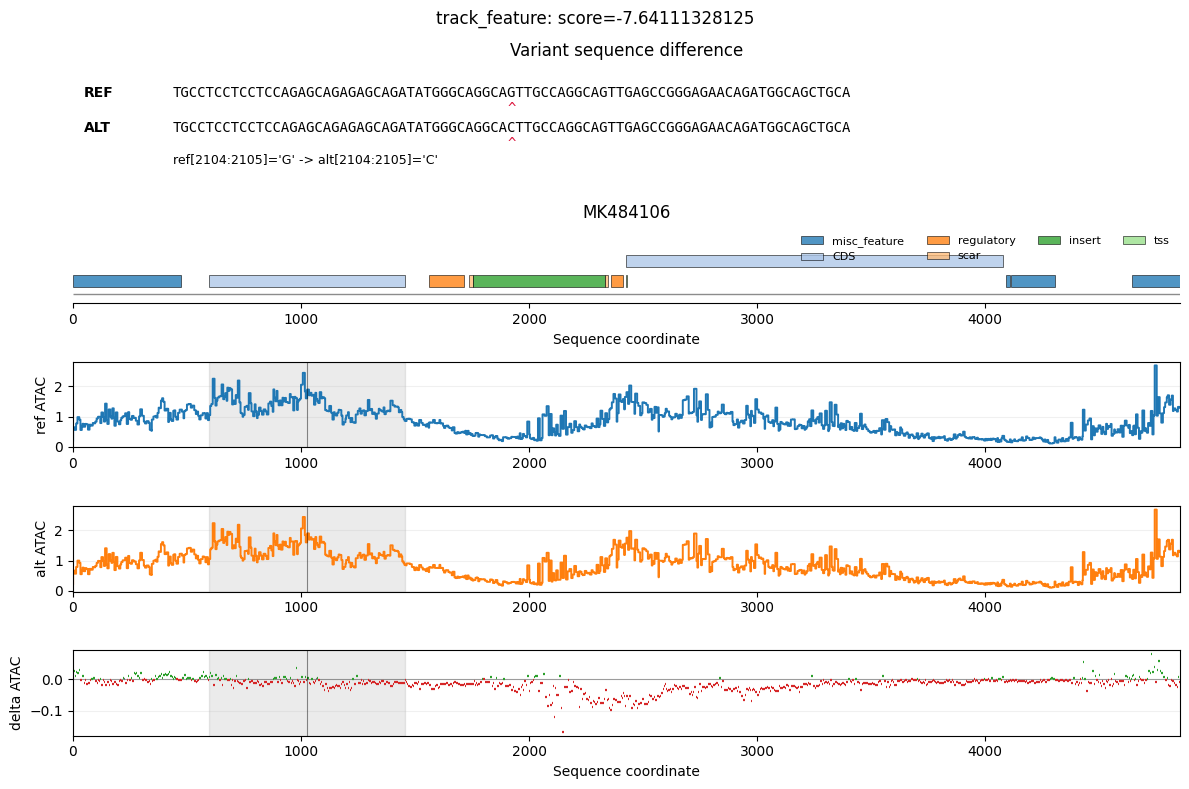

In [24]:
fig, (ax_variant, *axes) = result.plot_summary(include_annotations=True, annotation_kwargs={"label_features": False})

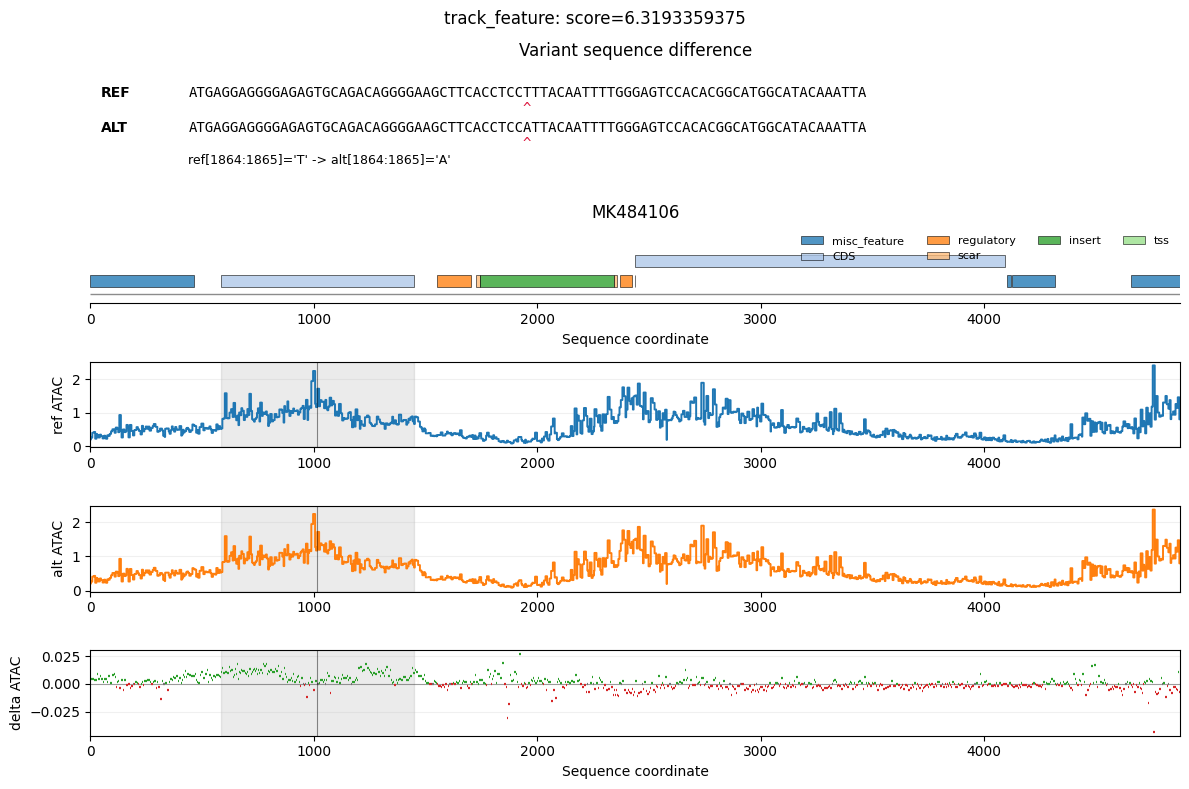

In [15]:
fig, (ax_variant, *axes) = result.plot_summary(include_annotations=True, annotation_kwargs={"label_features": False})

(<Figure size 1200x280 with 1 Axes>,
 <Axes: title={'center': 'MK484106'}, xlabel='Sequence coordinate'>)

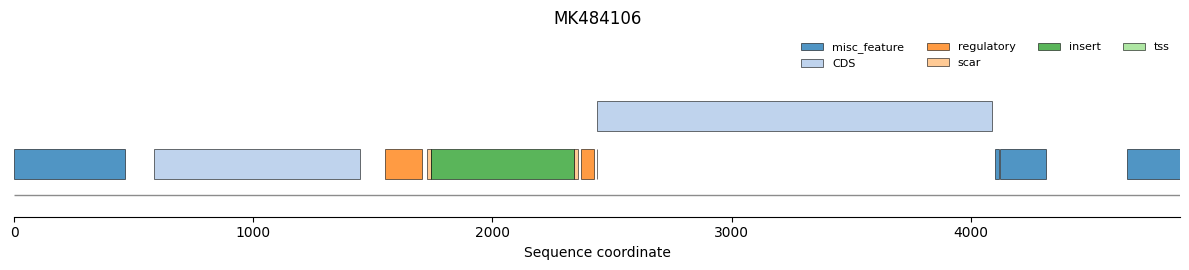

In [38]:
pair.alt.plot_annotations(label_features=False)

In [20]:
import polars as pl
dataset = pl.read_csv('/home/jovyan/.cache/mpramnist/data/Kircher/Kircher_GRCh38_ALL.tsv', separator='\t', infer_schema_length=10000)
variant_expr = pl.lit('chr') + pl.col('Chromosome').cast(pl.String) + pl.lit(':') + (pl.col('Position') + 1).cast(pl.String) + pl.lit(':') + pl.col('Ref').str.replace('-', '') + pl.lit('>') + pl.col('Alt').str.replace('-', '')
dataset = dataset.with_columns(variant = variant_expr)
dataset = dataset.filter(pl.col.Tags.__gt__(10))

In [15]:
scored = dataset.filter(pl.col.Element == 'BCL11A').sample(10).with_columns(model_prediction = pl.struct('variant', 'Element', 'Cell_Type').map_elements(lambda struct: score_variant(variant=struct['variant'],
                                                                                                                                                                    cell_type=struct['Cell_Type'],
                                                                                                                                                                    element=struct['Element']),
                                                                                                                                     return_dtype=pl.Float64))

Casting fp32 inputs back to torch.float16 for flash-attn compatibility.
10it [00:42,  1.47it/s]

In [39]:
dataset.filter(pl.col.Element == 'IRF4')

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str
"""IRF4""","""SK-MEL-28""","""6""",396142,"""G""","""-""",34,4909,3770,-0.12,0.45796,"""chr6:396143:G>"""
"""IRF4""","""SK-MEL-28""","""6""",396142,"""G""","""A""",608,60327,42920,-0.09,0.02007,"""chr6:396143:G>A"""
"""IRF4""","""SK-MEL-28""","""6""",396142,"""G""","""C""",392,34986,24767,-0.16,0.00079,"""chr6:396143:G>C"""
"""IRF4""","""SK-MEL-28""","""6""",396142,"""G""","""T""",259,21168,19223,0.17,0.00349,"""chr6:396143:G>T"""
"""IRF4""","""SK-MEL-28""","""6""",396143,"""G""","""-""",52,7529,5815,0.34,0.00747,"""chr6:396144:G>"""
…,…,…,…,…,…,…,…,…,…,…,…
"""IRF4""","""SK-MEL-28""","""6""",396591,"""G""","""T""",366,61096,44445,0.1,0.04451,"""chr6:396592:G>T"""
"""IRF4""","""SK-MEL-28""","""6""",396592,"""T""","""-""",112,7819,6174,0.14,0.11934,"""chr6:396593:T>"""
"""IRF4""","""SK-MEL-28""","""6""",396592,"""T""","""A""",508,100071,81203,0.14,0.00066,"""chr6:396593:T>A"""


In [ ]:
scored = dataset.filter(pl.col.Element == 'IRF4') \
                .sample(1000) \
                .with_columns(model_prediction = pl.struct('variant', 'Element', 'Cell_Type') \
                                                            .map_elements(lambda struct: score_variant(variant=struct['variant'],
                                                                                                                cell_type=struct['Cell_Type'],
                                                                                                                element=struct['Element']),
                                                                                        return_dtype=pl.Float64))

Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.


Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.


Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.


Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.

Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
Detected that you are using FX to symbolically trace a dynamo-optimized function. This is not supported at the moment.
The module hierarchy tracking seems to be messed up.Please file a bug to PyTorch.


In [38]:
scored.select(['model_prediction', 'Value']).corr()

model_prediction,Value
f64,f64
1.0,0.022181
0.022181,1.0


In [31]:
import matplotlib.pyplot as plt

In [33]:
scored

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value,variant,model_prediction
str,str,str,i64,str,str,i64,i64,i64,f64,f64,str,f64
"""BCL11A""","""HEL92.1.7""","""2""",60495489,"""G""","""A""",1102,22561,56676,0.0,0.9607,"""chr2:60495490:G>A""",-10.144531
"""BCL11A""","""HEL92.1.7""","""2""",60495386,"""T""","""C""",2444,47235,116043,-0.04,0.0075,"""chr2:60495387:T>C""",1.626221
"""BCL11A""","""HEL92.1.7""","""2""",60494955,"""G""","""A""",1215,23679,60156,0.07,0.00082,"""chr2:60494956:G>A""",-11.843994
"""BCL11A""","""HEL92.1.7""","""2""",60495433,"""A""","""T""",562,11226,28249,0.06,0.054,"""chr2:60495434:A>T""",-2.004883
"""BCL11A""","""HEL92.1.7""","""2""",60495205,"""C""","""-""",30,380,964,0.03,0.80327,"""chr2:60495206:C>""",6.471191
…,…,…,…,…,…,…,…,…,…,…,…,…
"""BCL11A""","""HEL92.1.7""","""2""",60495458,"""G""","""C""",188,3365,7997,-0.1,0.05777,"""chr2:60495459:G>C""",-8.314697
"""BCL11A""","""HEL92.1.7""","""2""",60495121,"""A""","""G""",1043,19766,47693,-0.01,0.73333,"""chr2:60495122:A>G""",-11.645752
"""BCL11A""","""HEL92.1.7""","""2""",60495252,"""T""","""C""",1665,31507,77321,-0.01,0.75805,"""chr2:60495253:T>C""",-4.418701


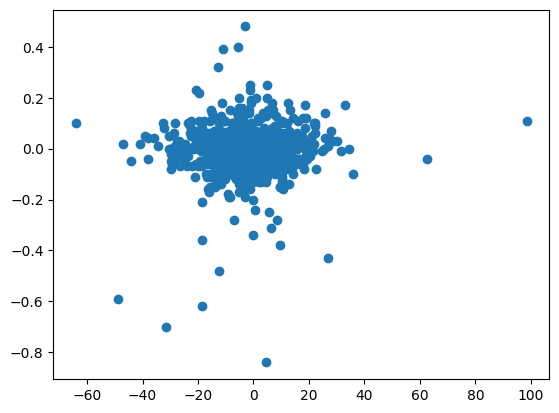

In [32]:
plt.scatter(x = scored.select(['model_prediction', 'Value'])['model_prediction'], y = scored.select(['model_prediction', 'Value'])['Value'])

In [ ]:
scored

In [26]:
genome_context = GenomeContext(length=501, center='variant')

In [ ]:
variant.to_sequence_pair(context=genome_context, genome = genome)

501

In [9]:
variant.as_feature()

Feature(name='variant', start=55112144, end=55112145, type='variant', strand='+', source='variant', metadata={'chrom': 'chr19', 'pos': 55112144, 'ref': 'T', 'alt': 'A', 'id': 'chr19:55112144:T:A', 'strand': '+', 'metadata': {}})